In [1]:
import matplotlib.pyplot as plt
import h5py, json, numpy as np
from scipy.optimize import minimize
from tqdm import tqdm
from pathlib import Path
import pickle

##### load equidistant measurement:

In [2]:
#config:
n_baseline_margin = 2
z_ixs_used = [0]

measurements_directory = '../datasets/OB300 fixed disks/'
if not Path(measurements_directory).exists():
    measurements_directory = '../madmax-datasets/OB300 fixed disks/'

files = sorted([p.name for p in Path(measurements_directory).glob('*.hdf5')])
if len(files) == 0:
    raise FileNotFoundError(f'No .hdf5 files found in: {measurements_directory}')

In [3]:
def apply_time_gating(
    s11,
    frequencies,
    x_pos,
    y_pos,
    z_pos,
    t_width=180e-9,
    t_offset=55e-9,
    c_const=299792458.0,
    edge_fraction=0.2,
):
    """
    Apply time-gating directly on S11 in the same spirit as
    1_Beadpull_Processing.ipynb / MADBead.time_gate_Delta_Gamma.

    Expected shapes:
      s11: (Nx, Ny, Nz, Nf) complex
      frequencies: (Nf,) in Hz
      x_pos, y_pos, z_pos in meters
    """
    s11 = np.asarray(s11)
    frequencies = np.asarray(frequencies, dtype=float).ravel()
    x_pos = np.asarray(x_pos, dtype=float).ravel()
    y_pos = np.asarray(y_pos, dtype=float).ravel()
    z_pos = np.asarray(z_pos, dtype=float).ravel()

    Nx, Ny, Nz, Nf = s11.shape
    if frequencies.size != Nf:
        raise ValueError("frequencies length must match last axis of s11")
    if Nf < 2:
        raise ValueError("Need at least 2 frequency points for time-domain transform")

    df = float(np.mean(np.diff(frequencies)))
    if not np.isfinite(df) or df <= 0:
        raise ValueError("frequencies must be strictly increasing and finite")

    taxis = np.fft.fftshift(np.fft.fftfreq(Nf, d=df))
    s11_t = np.fft.fftshift(np.fft.ifft(s11, axis=-1), axes=-1)

    mid_x = Nx // 2
    mid_y = Ny // 2
    t_bead_z = np.empty(Nz, dtype=float)
    for z in range(Nz):
        idx = np.argmax(np.abs(s11_t[mid_x, mid_y, z, :]))
        t_bead_z[z] = taxis[idx] + float(t_offset)

    if Nz >= 2:
        p = np.polyfit(z_pos, t_bead_z, 1)
        t_bead_fit_z = np.polyval(p, z_pos)
    else:
        t_bead_fit_z = np.full_like(z_pos, t_bead_z[0], dtype=float)

    r_axis = np.maximum((t_bead_fit_z * c_const / 2.0) ** 2, 0.0)
    t_bead_xyz = (
        2.0
        / c_const
        * np.sqrt(
            r_axis[None, None, :]
            + x_pos[:, None, None] ** 2
            + y_pos[None, :, None] ** 2
        )
    )

    t = taxis[None, None, None, :]
    center = t_bead_xyz[..., None]
    start = center - t_width / 2.0
    end = center + t_width / 2.0
    edge = max(float(t_width) * float(edge_fraction), np.finfo(float).eps)

    in_core = (t >= start) & (t <= end)
    in_rise = (t >= (start - edge)) & (t < start)
    in_fall = (t > end) & (t <= (end + edge))

    rise = 0.5 * (1.0 - np.cos(np.pi * (t - (start - edge)) / edge))
    fall = 0.5 * (1.0 + np.cos(np.pi * (t - end) / edge))

    gate = np.where(in_core, 1.0, np.where(in_rise, rise, np.where(in_fall, fall, 0.0)))

    s11_t_gated = s11_t * gate
    s11_gated = np.fft.fft(np.fft.ifftshift(s11_t_gated, axes=-1), axis=-1)

    return s11_gated, gate, taxis, t_bead_xyz

def _unwrap_with_period(phi, axis, period):
    """Compatibility wrapper for np.unwrap(..., period=...)."""
    try:
        return np.unwrap(phi, axis=axis, period=period)
    except TypeError:
        scale = 2.0 * np.pi / float(period)
        return np.unwrap(phi * scale, axis=axis) / scale

def calculate_sqrt_dgamma(delta_gamma, unwrap_xy=True):
    """
    Compute sqrt(DeltaGamma) while removing unphysical pi phase jumps from branch cuts.

    This follows the Julia logic:
      arg_wrapped = angle.(sqrt.(ΔΓ))
      arg_unwrapped = unwrap(arg_wrapped, dims=..., range=pi)
      sqrt_ΔΓ = sqrt(abs(ΔΓ)) * exp(1im * arg_unwrapped)
    """
    delta_gamma = np.asarray(delta_gamma)
    sqrt_abs = np.sqrt(np.abs(delta_gamma))
    arg_wrapped = np.angle(np.sqrt(delta_gamma))

    if not unwrap_xy:
        return sqrt_abs * np.exp(1j * arg_wrapped)

    arg_unwrapped = np.array(arg_wrapped, copy=True)

    if arg_unwrapped.ndim >= 4:
        # expected full grid ordering here: (x, y, z, f)
        # unwrap 2D in transverse plane for each (z, f)
        arg_unwrapped = _unwrap_with_period(arg_unwrapped, axis=0, period=np.pi)
        arg_unwrapped = _unwrap_with_period(arg_unwrapped, axis=1, period=np.pi)
    elif arg_unwrapped.ndim == 3:
        # line/reduced representation: unwrap along spatial coordinate
        arg_unwrapped = _unwrap_with_period(arg_unwrapped, axis=0, period=np.pi)
    elif arg_unwrapped.ndim == 2:
        arg_unwrapped = _unwrap_with_period(arg_unwrapped, axis=0, period=np.pi)
        arg_unwrapped = _unwrap_with_period(arg_unwrapped, axis=1, period=np.pi)
    elif arg_unwrapped.ndim == 1:
        arg_unwrapped = _unwrap_with_period(arg_unwrapped, axis=0, period=np.pi)

    return sqrt_abs * np.exp(1j * arg_unwrapped)


In [4]:
def load_file(file_path, time_gating=True, t_width=180e-9, t_offset=55e-9):
    with h5py.File(file_path, "r") as file:
        s11 = np.array(file['s11_map'])
        freq_info = json.loads(file.attrs['vna_config'])
        metadata = json.loads(file.attrs['measurement_config'])

    frequencies = np.linspace(freq_info['start'], freq_info['stop'], freq_info['points'])
    x_pos, y_pos, z_pos = [
        np.linspace(metadata['space'][ax][0], metadata['space'][ax][1], s11.shape[ax]) * 1e-3
        for ax in range(3)
    ]

    if time_gating:
        s11, _, _, _ = apply_time_gating(
            s11,
            frequencies,
            x_pos,
            y_pos,
            z_pos,
            t_width=t_width,
            t_offset=t_offset,
        )

    x_plt, y_plt = np.meshgrid(x_pos, y_pos, indexing='ij')
    x_pts, y_pts = x_plt.flatten(), y_plt.flatten()
    s11_z = s11[:, :, z_ixs_used, :]
    s11_flat = s11.reshape(-1, s11.shape[2], s11.shape[3])
    s11_z_flat = s11_z.reshape(-1, s11_z.shape[2], s11_z.shape[3])

    return s11, s11_flat, s11_z, s11_z_flat, frequencies, x_pos, x_plt, x_pts, y_pos, y_plt, y_pts, z_pos

##### plot functions:

In [5]:
def plot_point_selection(s11, frequencies, ixs, lines, x_pos, x_pts, y_pos, y_pts, z_pos, z_ix=0, f_ix=250, show_point_ix=False, show_line_ix=False):
    fig, ax = plt.subplots(figsize=(10, 5))

    # contour plot of |S11| at channel 0, frequency index 250
    cf = ax.contourf(x_pos, y_pos, np.abs(s11[:, :, z_ix, f_ix]).T, levels=20, cmap='viridis')
    fig.colorbar(cf, ax=ax, label='|S11|')

    # overlay all grid points in grey
    ax.scatter(x_pts, y_pts, s=10, c='grey', alpha=0.6, linewidths=0, label='grid points', zorder=3)

    # overlay lines y = a*x + b within plot bounds
    x_line = np.linspace(x_pos.min(), x_pos.max(), 400)
    for i, (a, b) in enumerate(lines):
        y_line = a * x_line + b
        mask = (y_line >= y_pos.min()) & (y_line <= y_pos.max())
        ax.plot(x_line[mask], y_line[mask], color='orange', linewidth=1, zorder=5, label='selection lines' if i == 0 else None)

        if show_line_ix and np.any(mask):
            # place label below the line near the middle of the visible segment
            x_seg = x_line[mask]
            y_seg = y_line[mask]
            mid = len(x_seg) // 2
            line_label_offset = 5.0  # in data units
            ax.text(x_seg[mid], y_seg[mid] - line_label_offset, f'Line {i}',
                    ha='center', va='top', fontsize=8, color='orange', zorder=6, clip_on=True)

    if show_point_ix:
        # handle indices or boolean mask
        ixs_arr = np.asarray(ixs)
        sel_idx = np.flatnonzero(ixs_arr) if ixs_arr.dtype == bool else ixs_arr.astype(int)
        # put index labels below each selected point
        y_offset = 2.0  # in data units
        for idx in sel_idx:
            ax.text(x_pts[idx], y_pts[idx] - y_offset, str(idx), ha='center', va='top', fontsize=7, color='red', zorder=6, clip_on=True)

    # overlay selected points in red
    ax.scatter(x_pts[ixs], y_pts[ixs], s=20, c='red', alpha=0.9, linewidths=0, label='selected points', zorder=4)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'|S11| at z={z_pos[z_ix]} mm, $\\nu$={frequencies[f_ix]*1e-9:.2f} GHz\nwith grid, selection lines and selected points')
    ax.legend(loc='upper left')

In [6]:
def plot_sqrt_Dgamma_line(
    lines,
    idxs_sorted_lines,
    s_sorted_lines,
    baseline_lines,
    sqrt_Dgamma_lines,
    line_index,
    n_baseline_margin,
    s11_flat,
    z_pos,
    frequencies,
    z_ix=0,
    f_ix=250,
):
    """
    Plot precomputed sqrt_Dgamma_lines[i] along the parametric line coordinate s for a given z_ix and f_ix.
    Highlights the first and last n_baseline_margin points used for baseline fitting,
    and overlays the precomputed linearly fitted baseline (on |S11|) for reference.

    Args:
        lines (list[tuple]): list of (a, b) for each line y = a*x + b.
        idxs_sorted_lines (list[np.ndarray]): list of sorted point indices per line.
        s_sorted_lines (list[np.ndarray]): list of sorted parametric coordinates s per line.
        baseline_lines (list[np.ndarray]): list of baseline arrays per line, shape (M, z, f).
        sqrt_Dgamma_lines (list[np.ndarray]): list of sqrt(DeltaGamma) per line, shape (M, z, f).
        line_index (int): index of the line to plot.
        n_baseline_margin (int): number of points at each end used for baseline fitting (for highlighting).
        z_ix (int): z index to plot.
        f_ix (int): frequency index to plot.
    """
    # sanity checks
    if not (0 <= line_index < len(lines)):
        raise ValueError(f"Line index i={line_index} out of range (0..{len(lines)-1}).")
    if z_ix < 0 or z_ix >= s11_flat.shape[1]:
        raise ValueError(f"z_ix out of range (0..{s11_flat.shape[1]-1}).")
    if f_ix < 0 or f_ix >= s11_flat.shape[2]:
        raise ValueError(f"f_ix out of range (0..{s11_flat.shape[2]-1}).")

    if (
        idxs_sorted_lines[line_index] is None
        or s_sorted_lines[line_index] is None
        or baseline_lines[line_index] is None
        or sqrt_Dgamma_lines[line_index] is None
    ):
        raise ValueError("Precomputed data for this line is missing (idxs/s/baseline/sqrt_Dgamma).")

    # precomputed per-line data
    idxs_sorted = idxs_sorted_lines[line_index]
    s_sorted = s_sorted_lines[line_index]
    baseline = baseline_lines[line_index][:, z_ix, f_ix]  # (M,)
    sqrt_dg = sqrt_Dgamma_lines[line_index][:, z_ix, f_ix]  # (M,)
    sqrt_dg_abs = np.abs(sqrt_dg)

    m_points = idxs_sorted.size
    if s_sorted.size != m_points or baseline.size != m_points or sqrt_dg.size != m_points:
        raise ValueError("Size mismatch among precomputed arrays for this line.")

    # baseline margin for highlighting
    n = min(n_baseline_margin, m_points // 2)
    if n == 0:
        raise ValueError("Baseline margin results in empty baseline set.")
    base_idx = np.r_[np.arange(n), np.arange(m_points - n, m_points)]

    # data along the line (complex S11) for selected (z,f)
    y_line = s11_flat[idxs_sorted, z_ix, f_ix]  # (M,)

    # parametric direction (for label only)
    a, b = lines[line_index]
    u = np.array([1.0, a], dtype=float)
    u /= np.linalg.norm(u)

    # plot
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # top: |S11| with baseline
    ax0.plot(s_sorted, np.abs(y_line), 'o', ms=4, alpha=0.7, label='|$\\Gamma$| (points)')
    ax0.plot(s_sorted, np.abs(baseline), '-', lw=2, color='tab:orange', label='|baseline| (fit)')
    ax0.plot(s_sorted[base_idx], np.abs(y_line[base_idx]), 'o', ms=6, color='red', label='baseline points')

    ax0.set_ylabel('|$\\Gamma$|')
    ax0.legend(loc='best')
    ax0.set_title(f'Line {line_index}: $y={a:.3f}x + {b:.3f}$ [mm], z={z_pos[z_ix]} mm, $\\nu$={frequencies[f_ix]*1e-9:.2f} GHz')
    ax0.grid()

    # bottom: |sqrt(DeltaGamma)|
    ax1.plot(s_sorted, sqrt_dg_abs, 'o-', ms=4, label='$|\\sqrt{\\Delta\\Gamma}|$')
    ax1.plot(s_sorted[base_idx], sqrt_dg_abs[base_idx], 'o', ms=6, color='red', label='baseline points')
    ax1.set_xlabel(f'$s={u[0]:.3f}x + {u[1]:.3f}y$ (line parameterization)')
    ax1.set_ylabel('$|\\sqrt{\\Delta\\Gamma}| \\propto |E|$')
    ax1.legend(loc='best')
    ax1.grid()

    plt.tight_layout()
    return fig, (ax0, ax1)

In [7]:
def plot_fitted_efield(params, x_plt, y_plt, x_reduced, y_reduced, e_field_reduced, e_field_full, beam_model, z_pos, frequencies, costs=None, z_ix=0, f_ix=250, overlay_points=True):
    """
    Figure 1: 2x3 comparison:
      - Top row: Fitted E-field
      - Bottom row: Full/Data E-field
      - Columns: |E|, Re(E), Im(E)
    Each subplot has its own colorbar, with matched limits per fit/data pair.
    Figure 2: Relative residual map in percent: 100 * (|data| - |fit|) / |data|.
    """
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    p = params[z_ix, f_ix]
    x0, y0, A, s = p[:4]
    kappa = float(p[4]) if p.size >= 5 else 0.0
    phi0 = float(p[5]) if p.size >= 6 else 0.0
    w = p[6:] if p.size > 6 else (1.0, 0.0, 0.0, 0.0)

    e_field_fit = beam_model(x_plt, y_plt, x0, y0, A, s, kappa, phi0, *w)
    e_fit_mag = np.abs(e_field_fit)
    e_fit_real = np.real(e_field_fit)
    e_fit_imag = np.imag(e_field_fit)

    e_field_data = e_field_full[:, :, z_ix, f_ix]
    e_data_mag = np.abs(e_field_data)
    e_data_real = np.real(e_field_data)
    e_data_imag = np.imag(e_field_data)

    overlay_mag = overlay_real = overlay_imag = None
    if overlay_points and e_field_reduced is not None:
        e_field_samples = np.asarray(e_field_reduced[:, z_ix, f_ix])
        overlay_mag = np.abs(e_field_samples)
        overlay_real = np.real(e_field_samples)
        overlay_imag = np.imag(e_field_samples)

    mag_vals = [e_fit_mag.ravel(), e_data_mag.ravel()]
    if overlay_mag is not None:
        mag_vals.append(np.asarray(overlay_mag).ravel())
    mag_all = np.concatenate(mag_vals)
    mag_vmin = np.nanpercentile(mag_all, 5)
    mag_vmax = np.nanpercentile(mag_all, 95)
    if not np.isfinite(mag_vmin) or not np.isfinite(mag_vmax) or mag_vmin == mag_vmax:
        mag_vmin, mag_vmax = np.nanmin(mag_all), np.nanmax(mag_all)
    if not np.isfinite(mag_vmin) or not np.isfinite(mag_vmax) or mag_vmin == mag_vmax:
        mag_vmin, mag_vmax = 0.0, 1.0

    real_vals = [e_fit_real.ravel(), e_data_real.ravel()]
    if overlay_real is not None:
        real_vals.append(np.asarray(overlay_real).ravel())
    real_all = np.concatenate(real_vals)
    real_lim = np.nanpercentile(np.abs(real_all), 95)
    if not np.isfinite(real_lim) or real_lim == 0:
        real_lim = np.nanmax(np.abs(real_all))
    if not np.isfinite(real_lim) or real_lim == 0:
        real_lim = 1.0

    imag_vals = [e_fit_imag.ravel(), e_data_imag.ravel()]
    if overlay_imag is not None:
        imag_vals.append(np.asarray(overlay_imag).ravel())
    imag_all = np.concatenate(imag_vals)
    imag_lim = np.nanpercentile(np.abs(imag_all), 95)
    if not np.isfinite(imag_lim) or imag_lim == 0:
        imag_lim = np.nanmax(np.abs(imag_all))
    if not np.isfinite(imag_lim) or imag_lim == 0:
        imag_lim = 1.0

    residual = e_data_mag - e_fit_mag
    denom = np.where(e_data_mag > np.finfo(float).eps, e_data_mag, np.nan)
    rel_residual = 100.0 * residual / denom
    rmaxp = np.nanpercentile(np.abs(rel_residual), 95)
    if not np.isfinite(rmaxp) or rmaxp == 0:
        rmaxp = np.nanmax(np.abs(rel_residual))
    if not np.isfinite(rmaxp) or rmaxp == 0:
        rmaxp = 1.0

    fig_top, ax = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=False)
    fig_top.subplots_adjust(left=0.06, right=0.97, bottom=0.08, top=0.93, wspace=0.35, hspace=0)
    ax00, ax01, ax02 = ax[0, 0], ax[0, 1], ax[0, 2]
    ax10, ax11, ax12 = ax[1, 0], ax[1, 1], ax[1, 2]

    c0_fit = ax00.contourf(x_plt, y_plt, e_fit_mag, levels=30, cmap='viridis', vmin=mag_vmin, vmax=mag_vmax)
    c0_data = ax10.contourf(x_plt, y_plt, e_data_mag, levels=30, cmap='viridis', vmin=mag_vmin, vmax=mag_vmax)
    cax00 = make_axes_locatable(ax00).append_axes('right', size='4%', pad=0.08)
    cax10 = make_axes_locatable(ax10).append_axes('right', size='4%', pad=0.08)
    fig_top.colorbar(c0_fit, cax=cax00, label='|E|')
    fig_top.colorbar(c0_data, cax=cax10, label='|E|')
    if overlay_mag is not None and x_reduced is not None and y_reduced is not None:
        ax00.scatter(
            x_reduced, y_reduced, c=overlay_mag,
            cmap='viridis', vmin=mag_vmin, vmax=mag_vmax,
            s=25, edgecolors='k', linewidths=0.2, alpha=0.9, label='data points'
        )
        ax00.legend(loc='upper right')

    c1_fit = ax01.contourf(x_plt, y_plt, e_fit_real, levels=30, cmap='RdBu_r', vmin=-real_lim, vmax=real_lim)
    c1_data = ax11.contourf(x_plt, y_plt, e_data_real, levels=30, cmap='RdBu_r', vmin=-real_lim, vmax=real_lim)
    cax01 = make_axes_locatable(ax01).append_axes('right', size='4%', pad=0.08)
    cax11 = make_axes_locatable(ax11).append_axes('right', size='4%', pad=0.08)
    fig_top.colorbar(c1_fit, cax=cax01, label='Re(E)')
    fig_top.colorbar(c1_data, cax=cax11, label='Re(E)')
    if overlay_real is not None and x_reduced is not None and y_reduced is not None:
        ax01.scatter(
            x_reduced, y_reduced, c=overlay_real,
            cmap='RdBu_r', vmin=-real_lim, vmax=real_lim,
            s=25, edgecolors='k', linewidths=0.2, alpha=0.9, label='data points'
        )
        ax01.legend(loc='upper right')

    c2_fit = ax02.contourf(x_plt, y_plt, e_fit_imag, levels=30, cmap='RdBu_r', vmin=-imag_lim, vmax=imag_lim)
    c2_data = ax12.contourf(x_plt, y_plt, e_data_imag, levels=30, cmap='RdBu_r', vmin=-imag_lim, vmax=imag_lim)
    cax02 = make_axes_locatable(ax02).append_axes('right', size='4%', pad=0.08)
    cax12 = make_axes_locatable(ax12).append_axes('right', size='4%', pad=0.08)
    fig_top.colorbar(c2_fit, cax=cax02, label='Im(E)')
    fig_top.colorbar(c2_data, cax=cax12, label='Im(E)')
    if overlay_imag is not None and x_reduced is not None and y_reduced is not None:
        ax02.scatter(
            x_reduced, y_reduced, c=overlay_imag,
            cmap='RdBu_r', vmin=-imag_lim, vmax=imag_lim,
            s=25, edgecolors='k', linewidths=0.2, alpha=0.9, label='data points'
        )
        ax02.legend(loc='upper right')

    title_fit = f'Fitted E-field at z={z_pos[z_ix]} m, ν={frequencies[f_ix]*1e-9:.2f} GHz'
    if costs is not None:
        title_fit += f', MSE cost={float(costs[z_ix, f_ix]):.3e}'
    ax00.set_title(title_fit)
    ax01.set_title('Fitted Re(E)')
    ax02.set_title('Fitted Im(E)')
    ax10.set_title('Data |E| (all points)')
    ax11.set_title('Data Re(E) (all points)')
    ax12.set_title('Data Im(E) (all points)')

    axes = (ax00, ax01, ax02, ax10, ax11, ax12)
    for axi in axes:
        axi.set_xlabel('x [mm]')
        axi.set_ylabel('y [mm]')
        axi.set_aspect('equal', adjustable='box')
        axi.grid(True, alpha=0.2)

    fig_res = plt.figure(figsize=(10, 5), constrained_layout=True)
    axr = fig_res.add_subplot(111)
    cfr = axr.contourf(x_plt, y_plt, rel_residual, levels=30, cmap='coolwarm', vmin=-rmaxp, vmax=rmaxp)
    fig_res.colorbar(cfr, ax=axr, label='Residual (% of data)')
    axr.set_title('Residual (data - fit) [%]')
    axr.set_xlabel('x [mm]')
    axr.set_ylabel('y [mm]')
    axr.set_aspect('equal', adjustable='box')
    axr.grid(True, alpha=0.2)

    return fig_top, axes, fig_res, axr

def plot_sqrt_dgamma_before_after_correction(
    sqrt_dgamma_full,
    sqrt_dgamma_reduced_before,
    sqrt_dgamma_reduced_after,
    all_ixs,
    z_ix=0,
    f_ix=250,
    colors=('tab:orange', 'tab:blue'),
    labels=('before correction', 'after correction'),
    title_prefix='',
):
    """
    Scatter comparisons at line points for |sqrt(ΔΓ)|, Re(sqrt(ΔΓ)), Im(sqrt(ΔΓ)).
    In each subplot, both before and after corrected reduced values are shown against full values.
    """
    full_line = np.asarray(sqrt_dgamma_full).reshape(-1, sqrt_dgamma_full.shape[2], sqrt_dgamma_full.shape[3])[all_ixs, z_ix, f_ix]
    red_before = np.asarray(sqrt_dgamma_reduced_before)[:, z_ix, f_ix]
    red_after = np.asarray(sqrt_dgamma_reduced_after)[:, z_ix, f_ix]

    valid = np.isfinite(full_line) & np.isfinite(red_before) & np.isfinite(red_after)
    full_line = full_line[valid]
    red_before = red_before[valid]
    red_after = red_after[valid]

    if full_line.size == 0:
        raise ValueError('No valid overlapping line-point samples for plotting.')

    def _lims(xv, yv1, yv2):
        lo = np.nanmin(np.r_[xv, yv1, yv2])
        hi = np.nanmax(np.r_[xv, yv1, yv2])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = -1.0, 1.0
        pad = 0.05 * (hi - lo)
        return lo - pad, hi + pad

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    comps = [
        (np.abs(full_line), np.abs(red_before), np.abs(red_after), r'|sqrt(ΔΓ)|'),
        (np.real(full_line), np.real(red_before), np.real(red_after), r'Re(sqrt(ΔΓ))'),
        (np.imag(full_line), np.imag(red_before), np.imag(red_after), r'Im(sqrt(ΔΓ))'),
    ]

    for ax, (xv, yb, ya, name) in zip(axes, comps):
        ax.scatter(xv, yb, s=22, label=labels[0], marker='o', edgecolors=colors[0], linewidths=0.8, facecolors='none')
        ax.scatter(xv, ya, s=22, label=labels[1], marker='o', edgecolors=colors[1], linewidths=0.8, facecolors='none')
        lo, hi = _lims(xv, yb, ya)
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel(f'full {name}')
        ax.set_ylabel(f'reduced {name}')
        ax.set_title(name)
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc='best')
    fig.suptitle(f'{title_prefix} sqrt(ΔΓ) at line points, z_ix={z_ix}, f_ix={f_ix}', y=1.03)

    return fig, axes

In [8]:
def plot_beta_overlay(beta_reduced, beta_full, frequencies, colors=('tab:blue', 'tab:red')):
    """
    Plot beta_reduced and beta_full on the same panel with a shared x-axis (frequency),
    but separate y-axes. Make curves more distinguishable via line style, width, markers, and alpha.
    """
    freq_ghz = np.asarray(frequencies) * 1e-9

    # sparse markers to avoid clutter even if curves overlap
    N = freq_ghz.size
    step = max(1, N // 40)

    fig, ax_left = plt.subplots(figsize=(9, 4))
    l1 = ax_left.plot(
        freq_ghz, beta_reduced,
        color=colors[0], lw=1.0, linestyle='--',
        marker='o', ms=3, markevery=step,
        alpha=0.9, zorder=3, label='β from reduced BP'
    )
    ax_left.set_xlim(19, 20)
    ax_left.set_xlabel('Frequency (GHz)')
    ax_left.set_ylabel('β (a.u.)')
    ax_left.tick_params(axis='y')
    ax_left.grid(True, which='both', alpha=0.3)

    l2 = ax_left.plot(
        freq_ghz, beta_full,
        color=colors[1], lw=1.0, linestyle='-',
        marker='s', ms=3, markevery=(step // 2, step),
        alpha=0.9, zorder=2, label='β from full BP'
    )
    # distinct dash pattern for the right line
    l2[0].set_dashes((6, 2))

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax_left.legend(lines, labels, loc='upper right')

    plt.tight_layout()
    #return fig, ax_left

In [9]:
def plot_ET_complex_plane(ETs_full, ETs_reduced, z_full, z_reduced, f_ix=250, z_decimals=2):
    """
    Scatter plot of ET values in the complex plane at one frequency index.

    - Full set is shown only at z-positions that are present in z_reduced.
    - x-axis: Re(ET), y-axis: Im(ET).
    - Each point is annotated with its corresponding z-value in mm.
    """
    ETs_full = np.asarray(ETs_full)
    ETs_reduced = np.asarray(ETs_reduced)
    z_full = np.asarray(z_full).ravel()
    z_reduced = np.asarray(z_reduced).ravel()

    if ETs_full.ndim != 2 or ETs_reduced.ndim != 2:
        raise ValueError("ETs_full and ETs_reduced must be 2D arrays of shape (z, f).")
    if z_full.size != ETs_full.shape[0]:
        raise ValueError("Length of z_full must match ETs_full.shape[0].")
    if z_reduced.size != ETs_reduced.shape[0]:
        raise ValueError("Length of z_reduced must match ETs_reduced.shape[0].")
    if not (0 <= f_ix < ETs_full.shape[1] and 0 <= f_ix < ETs_reduced.shape[1]):
        raise ValueError("f_ix is out of range for ET arrays.")

    # match each reduced z to nearest z in full set
    ix_z_full_matched = [int(np.argmin(np.abs(z_full - zr))) for zr in z_reduced]

    full_vals = ETs_full[ix_z_full_matched, f_ix]
    reduced_vals = ETs_reduced[:, f_ix]

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(
        np.real(full_vals),
        np.imag(full_vals),
        label='Full Set (at z_reduced)',
        marker='o',
        s=100,
        alpha=0.7
    )
    ax.scatter(
        np.real(reduced_vals),
        np.imag(reduced_vals),
        label='Reduced Set',
        marker='x',
        s=100,
        alpha=0.8
    )

    for i, zr in enumerate(z_reduced):
        z_mm = zr * 1e3
        z_label = f"z={z_mm:.{z_decimals}f} mm"
        ax.annotate(
            z_label,
            (np.real(full_vals[i]), np.imag(full_vals[i])),
            xytext=(5, 5),
            textcoords='offset points',
            color='tab:blue'
        )
        ax.annotate(
            z_label,
            (np.real(reduced_vals[i]), np.imag(reduced_vals[i])),
            xytext=(5, -15),
            textcoords='offset points',
            color='tab:orange'
        )

    ax.set_xlabel('Re(ET)')
    ax.set_ylabel('Im(ET)')
    ax.set_title(f'ET values in complex plane at f_ix={f_ix}')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    return fig, ax

def plot_abs_ET_over_z(ETs_full, ETs_reduced, z_full, z_reduced, f_ix=250, z_decimals=2, atol=1e-9):
    """
    Plot |ET| over z at one frequency index.

    - x-axis: z in mm.
    - y-axis: |ET|.
    - Full set is restricted to z_full values that are also present in z_reduced.
    """
    ETs_full = np.asarray(ETs_full)
    ETs_reduced = np.asarray(ETs_reduced)
    z_full = np.asarray(z_full).ravel()
    z_reduced = np.asarray(z_reduced).ravel()

    if ETs_full.ndim != 2 or ETs_reduced.ndim != 2:
        raise ValueError("ETs_full and ETs_reduced must be 2D arrays of shape (z, f).")
    if z_full.size != ETs_full.shape[0]:
        raise ValueError("Length of z_full must match ETs_full.shape[0].")
    if z_reduced.size != ETs_reduced.shape[0]:
        raise ValueError("Length of z_reduced must match ETs_reduced.shape[0].")
    if not (0 <= f_ix < ETs_full.shape[1] and 0 <= f_ix < ETs_reduced.shape[1]):
        raise ValueError("f_ix is out of range for ET arrays.")

    # keep only z_reduced entries that have a matching value in z_full
    pairs = []
    for i_red, zr in enumerate(z_reduced):
        is_match = np.isclose(z_full, zr, atol=atol, rtol=0.0)
        if np.any(is_match):
            i_full = int(np.flatnonzero(is_match)[0])
            pairs.append((i_full, i_red))

    if len(pairs) == 0:
        raise ValueError("No overlapping z values found between z_full and z_reduced (within atol).")

    full_idx = np.array([p[0] for p in pairs], dtype=int)
    red_idx = np.array([p[1] for p in pairs], dtype=int)

    z_plot = z_reduced[red_idx]
    full_abs = np.abs(ETs_full[full_idx, f_ix])
    red_abs = np.abs(ETs_reduced[red_idx, f_ix])

    order = np.argsort(z_plot)
    z_plot = z_plot[order]
    full_abs = full_abs[order]
    red_abs = red_abs[order]
    z_plot_mm = z_plot * 1e3

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(z_plot_mm, full_abs, 'o-', label='|ET| Full (z overlap)', alpha=0.8)
    ax.plot(z_plot_mm, red_abs, 'x--', label='|ET| Reduced', alpha=0.8)

    if z_decimals is not None:
        for z_mm, y in zip(z_plot_mm, red_abs):
            ax.annotate(f"{z_mm:.{z_decimals}f} mm", (z_mm, y), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=8, color='tab:orange')

    ax.set_xlabel('z [mm]')
    ax.set_ylabel('|ET|')
    ax.set_title(f'|ET| over z at f_ix={f_ix}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    return fig, ax

In [10]:
def plot_abs_ET_grid_over_frequency(
    ETs_full,
    ETs_reduced,
    z_full,
    z_reduced,
    frequencies,
    z_decimals=2,
    atol=1e-9,
    max_et_for_scaling=500.0,
    colors=("tab:blue", "tab:red"),
    colors_real=("tab:green", "tab:orange"),
    colors_imag=("tab:purple", "tab:brown"),
    reduced_linewidth=1.0,
    full_linewidth=1.0,
    reduced_alpha=0.75,
    full_alpha=0.65,
    reduced_linestyle="-",
    full_linestyle=(0, (4, 2)),
    return_all=False,
):
    """
    Plot ET over frequency for each reduced z-slice in a 2-column grid.

    Creates three figures with identical grid layout:
      - |ET| (magnitude)
      - Re(ET)
      - Im(ET)

    Each subplot contains reduced and full curves for the same (matched) z value.
    Axis scaling ignores outliers with absolute value > max_et_for_scaling.

    Styling defaults are tuned so both curves remain visible in overlap regions:
      - thinner lines
      - semi-transparency for both
      - dashed full-data curve

    Returns (default, backward compatible):
        fig_abs, axes_abs, ix_z_full_matched

    Returns (if return_all=True):
        (fig_abs, axes_abs), (fig_real, axes_real), (fig_imag, axes_imag), ix_z_full_matched
    """
    ETs_full = np.asarray(ETs_full)
    ETs_reduced = np.asarray(ETs_reduced)
    z_full = np.asarray(z_full).ravel()
    z_reduced = np.asarray(z_reduced).ravel()
    frequencies = np.asarray(frequencies, dtype=float).ravel()

    if ETs_full.ndim != 2 or ETs_reduced.ndim != 2:
        raise ValueError("ETs_full and ETs_reduced must be 2D arrays of shape (z, f).")
    if z_full.size != ETs_full.shape[0]:
        raise ValueError("Length of z_full must match ETs_full.shape[0].")
    if z_reduced.size != ETs_reduced.shape[0]:
        raise ValueError("Length of z_reduced must match ETs_reduced.shape[0].")
    if frequencies.size != ETs_full.shape[1] or frequencies.size != ETs_reduced.shape[1]:
        raise ValueError("Length of frequencies must match ET arrays' frequency dimension.")

    n = z_reduced.size
    if n == 0:
        raise ValueError("z_reduced is empty; nothing to plot.")

    max_et_for_scaling = float(max_et_for_scaling)
    if max_et_for_scaling <= 0.0 or not np.isfinite(max_et_for_scaling):
        raise ValueError("max_et_for_scaling must be a positive finite number.")

    reduced_alpha = float(reduced_alpha)
    full_alpha = float(full_alpha)
    if not (0.0 < reduced_alpha <= 1.0):
        raise ValueError("reduced_alpha must be in the interval (0, 1].")
    if not (0.0 < full_alpha <= 1.0):
        raise ValueError("full_alpha must be in the interval (0, 1].")

    def _as_palette(palette, name):
        if palette is None:
            raise ValueError(f"{name} must be a length-2 tuple/list of colors.")
        palette = tuple(palette)
        if len(palette) != 2:
            raise ValueError(f"{name} must contain exactly 2 colors (reduced, full).")
        return palette

    palette_abs = _as_palette(colors, "colors")
    palette_real = _as_palette(colors_real, "colors_real")
    palette_imag = _as_palette(colors_imag, "colors_imag")

    # Map each reduced z to a matching full z index (exact within atol, else nearest).
    ix_z_full_matched = np.empty(n, dtype=int)
    for i, zr in enumerate(z_reduced):
        matches = np.flatnonzero(np.isclose(z_full, zr, atol=atol, rtol=0.0))
        if matches.size > 0:
            ix_z_full_matched[i] = int(matches[0])
        else:
            ix_z_full_matched[i] = int(np.argmin(np.abs(z_full - zr)))

    freq_ghz = frequencies * 1e-9
    n_cols = 2
    n_rows = int(np.ceil(n / n_cols))

    def _component_ylim(y_reduced, y_full, symmetric):
        vals = np.r_[
            y_reduced[np.isfinite(y_reduced) & (np.abs(y_reduced) <= max_et_for_scaling)],
            y_full[np.isfinite(y_full) & (np.abs(y_full) <= max_et_for_scaling)],
        ]

        if vals.size == 0:
            lim = max_et_for_scaling
        elif symmetric:
            lim = float(np.nanmax(np.abs(vals)))
            lim = max(lim, np.finfo(float).eps)
        else:
            lim = float(np.nanmax(vals))
            lim = max(lim, np.finfo(float).eps)

        if symmetric:
            return -1.05 * lim, 1.05 * lim
        return 0.0, 1.05 * lim

    def _plot_grid(component_fn, ylabel, title, palette, symmetric=False):
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(12, 3.6 * n_rows),
            sharex=True,
            constrained_layout=True,
        )
        axes = np.atleast_1d(axes).ravel()

        for i in range(n):
            ax = axes[i]
            y_reduced = component_fn(ETs_reduced[i, :])
            y_full = component_fn(ETs_full[ix_z_full_matched[i], :])

            reduced_line = ax.plot(
                freq_ghz,
                y_reduced,
                color=palette[0],
                lw=reduced_linewidth,
                alpha=reduced_alpha,
                linestyle=reduced_linestyle,
                zorder=2,
                label=f"{ylabel} reduced",
            )[0]

            full_line = ax.plot(
                freq_ghz,
                y_full,
                color=palette[1],
                lw=full_linewidth,
                alpha=full_alpha,
                linestyle=full_linestyle,
                zorder=3,
                label=f"{ylabel} full",
            )[0]

            y0, y1 = _component_ylim(y_reduced, y_full, symmetric=symmetric)
            ax.set_ylim(y0, y1)

            z_mm = z_reduced[i] * 1e3
            ax.set_title(f"z={z_mm:.{z_decimals}f} mm")
            ax.set_xlabel("Frequency [GHz]")
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            ax.legend(handles=[reduced_line, full_line], loc="best")

        for j in range(n, axes.size):
            axes[j].set_visible(False)

        fig.suptitle(title, y=1.02)
        return fig, axes[:n]

    fig_abs, axes_abs = _plot_grid(
        component_fn=lambda x: np.abs(x),
        ylabel="|ET|",
        title="|ET| over frequency per reduced z-slice (reduced vs full)",
        palette=palette_abs,
        symmetric=False,
    )

    fig_real, axes_real = _plot_grid(
        component_fn=lambda x: np.real(x),
        ylabel="Re(ET)",
        title="Re(ET) over frequency per reduced z-slice (reduced vs full)",
        palette=palette_real,
        symmetric=True,
    )

    fig_imag, axes_imag = _plot_grid(
        component_fn=lambda x: np.imag(x),
        ylabel="Im(ET)",
        title="Im(ET) over frequency per reduced z-slice (reduced vs full)",
        palette=palette_imag,
        symmetric=True,
    )

    if return_all:
        return (fig_abs, axes_abs), (fig_real, axes_real), (fig_imag, axes_imag), ix_z_full_matched

    return fig_abs, axes_abs, ix_z_full_matched

##### full $\sqrt{\Delta\Gamma}$ calculation:

In [11]:
def compute_sqrt_Dgamma_full(s11, x_pos, y_pos, z_pos, n_baseline_margin):
    Nx, Ny, Nz, Nf = s11.shape
    n = min(int(n_baseline_margin), Nx // 2)
    if n <= 0:
        raise ValueError("n_baseline_margin must be >= 1 and less than half the number of x points.")

    # indices of baseline points along each y-row (first n and last n x positions)
    baseline_ix = np.r_[np.arange(n), np.arange(Nx - n, Nx)]
    m = baseline_ix.size

    # precompute x sums for least-squares
    s_base = x_pos[baseline_ix]                 # (m,)
    sum_s = s_base.sum()
    sum_s2 = (s_base ** 2).sum()
    den = m * sum_s2 - sum_s ** 2

    delta_gamma_full = np.empty(s11.shape, dtype=np.complex128)

    for j in range(Ny):  # iterate over y-rows
        # gather baseline samples for all (z,f) on this y-row
        y_base = s11[baseline_ix, j, :, :]      # (m, Nz, Nf)

        # least-squares fit of complex baseline: y ≈ beta0 + beta1 * x
        sum_y = y_base.sum(axis=0)                              # (Nz, Nf)
        sum_sy = (s_base[:, None, None] * y_base).sum(axis=0)   # (Nz, Nf)

        if den == 0:
            beta0 = y_base.mean(axis=0)
            beta1 = np.zeros_like(beta0)
        else:
            beta0 = (sum_s2 * sum_y - sum_s * sum_sy) / den
            beta1 = (m * sum_sy - sum_s * sum_y) / den

        # evaluate baseline for all x along this y-row
        base_row = beta0[None, :, :] + beta1[None, :, :] * x_pos[:, None, None]   # (Nx, Nz, Nf)

        # DeltaGamma = s11 - baseline
        delta_gamma_full[:, j, :, :] = s11[:, j, :, :] - base_row

    return calculate_sqrt_dgamma(delta_gamma_full, unwrap_xy=True)

##### full $E_T$ calculation:

In [12]:
def sqrt_dgamma_to_E(sqrt_dgamma, frequencies):
    # scale sqrt_dgamma to E-field units using the same convention as the Julia snippet
    eps_b = 9.23
    delta_eps = eps_b - 1.0
    r_b = (2.93e-3) / 2.0
    V_b = 4.0 / 3.0 * np.pi * r_b ** 3
    alpha_0 = 3.0 * delta_eps * V_b / (eps_b + 2.0)

    P_in = 1.0
    epsilon0 = 8.85418782e-12

    nu_hz = np.asarray(frequencies, dtype=float).ravel()
    conv = np.sqrt(4.0 * P_in / (epsilon0 * alpha_0 * 1j * 2.0 * np.pi * nu_hz))
    conv_shape = (1,) * (sqrt_dgamma.ndim - 1) + (conv.size,)
    return sqrt_dgamma * conv.reshape(conv_shape)

In [13]:
def compute_ET_full(field_full, x_pos, y_pos, frequencies):
    ET_full = field_full
    return np.nansum(ET_full, axis=(0, 1)) * np.mean(np.diff(x_pos)) * np.mean(np.diff(y_pos))

##### Reduced Point Cloud Calculation:

In [14]:
def reduce_points_to_lines(s11_z_flat, x_pts, y_pts):
    def points_near_lines(lines, tol=2):
        lines = np.asarray(lines, dtype=float)
        a = lines[:, 0]
        b = lines[:, 1]
        residuals = np.abs(y_pts[:, None] - (x_pts[:, None] * a[None, :] + b[None, :]))
        per_line_masks = (residuals <= tol)
        any_mask = per_line_masks.any(axis=1)
        return any_mask, per_line_masks.T

    lines = [
        (.15, 80*1e-3),
        (-.15, 40*1e-3),
        (.15, 0),
        (-.15, -40*1e-3)
    ]
    all_ixs, per_line_ixs = points_near_lines(lines, tol=3*1e-3)
    s11_reduced = s11_z_flat[all_ixs, :, :]
    x_reduced = x_pts[all_ixs]
    y_reduced = y_pts[all_ixs]
    
    return s11_reduced, x_reduced, y_reduced, lines, all_ixs, per_line_ixs

##### $\sqrt{\Delta\Gamma}$ reduced calculation:

In [15]:
def compute_sqrt_Dgamma_lines(s11_z_flat, x_pts, y_pts, lines, per_line_ixs, all_ixs, n_baseline_margin):
    # linear baseline subtraction per line using least-squares fit along the tilted line direction
    sqrt_Dgamma = np.empty(s11_z_flat.shape, dtype=np.complex128)
    sqrt_Dgamma_lines = [None] * len(lines)

    # store precomputed per-line arrays for plotting
    baseline_lines = [None] * len(lines)
    s_sorted_lines = [None] * len(lines)
    idxs_sorted_lines = [None] * len(lines)

    for line_index, (a, b) in enumerate(lines):
        mask = per_line_ixs[line_index]
        idxs = np.flatnonzero(mask)
        if idxs.size < 2:
            continue

        # parametric coordinate s along the line direction (accounts for tilt)
        u = np.array([1.0, a], dtype=float)
        u /= np.linalg.norm(u)  # normalize direction vector
        s_all = u[0] * x_pts[idxs] + u[1] * y_pts[idxs]

        # order points along the line by s
        order = np.argsort(s_all)
        idxs_sorted = idxs[order]
        s_all_sorted = s_all[order]
        m_points = idxs_sorted.size

        # take first and last n points as baseline set
        n = min(n_baseline_margin, m_points // 2)
        if n == 0:
            continue

        s_base = np.concatenate([s_all_sorted[:n], s_all_sorted[-n:]])
        y_base = s11_z_flat[np.concatenate([idxs_sorted[:n], idxs_sorted[-n:]]), :, :]  # (M,z,f)

        # least-squares fit y ≈ beta0 + beta1 * s for each (z,f)
        m = s_base.size
        sum_s = s_base.sum()
        sum_s2 = (s_base ** 2).sum()
        sum_y = y_base.sum(axis=0)  # (z,f)
        sum_sy = (s_base[:, None, None] * y_base).sum(axis=0)  # (z,f)

        den = m * sum_s2 - sum_s ** 2
        if den == 0:
            beta0 = y_base.mean(axis=0)
            beta1 = np.zeros_like(beta0)
        else:
            beta0 = (sum_s2 * sum_y - sum_s * sum_sy) / den
            beta1 = (m * sum_sy - sum_s * sum_y) / den

        # evaluate baseline for all points on the line using s_all_sorted
        base = beta0[None, :, :] + beta1[None, :, :] * s_all_sorted[:, None, None]  # (M,z,f)

        # subtract to obtain delta_gamma and compute sqrt with pi-phase unwrapping
        delta_gamma_line = s11_z_flat[idxs_sorted, :, :] - base
        sqrt_Dgamma_line = calculate_sqrt_dgamma(delta_gamma_line, unwrap_xy=True)
        sqrt_Dgamma[idxs_sorted, :, :] = sqrt_Dgamma_line
        sqrt_Dgamma_lines[line_index] = sqrt_Dgamma_line

        # store for plotting
        baseline_lines[line_index] = base
        s_sorted_lines[line_index] = s_all_sorted
        idxs_sorted_lines[line_index] = idxs_sorted

    # convenience: delta_gamma for the reduced point cloud
    sqrt_Dgamma_reduced = sqrt_Dgamma[all_ixs]
    return sqrt_Dgamma_reduced, sqrt_Dgamma_lines, baseline_lines, s_sorted_lines, idxs_sorted_lines

def correct_sqrt_dgamma_reduced_with_full(
    sqrt_dgamma_full,
    sqrt_Dgamma_lines,
    idxs_sorted_lines,
    all_ixs,
    z_ixs_used,
):
    """
    Correct reduced sqrt(ΔΓ) using full-grid sqrt(ΔΓ) at the same line points.

    For each line and each reduced (z,f):
      1) detect local pi-branch flips (sign from Re(red * conj(full)))
      2) apply per-line complex least-squares scale after sign correction

    Args:
      z_ixs_used: mapping from reduced z-index -> full z-index.

    Returns:
      sqrt_Dgamma_reduced_corr: corrected reduced cloud in all_ixs ordering, shape (Nred, Zred, F)
      sqrt_Dgamma_lines_corr: corrected per-line arrays with original line ordering
    """
    full_flat = np.asarray(sqrt_dgamma_full).reshape(-1, sqrt_dgamma_full.shape[2], sqrt_dgamma_full.shape[3])

    # infer reduced dimensions from first available line
    first_line = next((arr for arr in sqrt_Dgamma_lines if arr is not None), None)
    if first_line is None:
        raise ValueError('No line data available in sqrt_Dgamma_lines.')
    Zred, F = first_line.shape[1], first_line.shape[2]

    z_map = np.asarray(z_ixs_used, dtype=int).ravel()
    if z_map.size != Zred:
        raise ValueError(f'z_ixs_used has length {z_map.size}, expected {Zred} to match reduced z dimension.')

    sqrt_Dgamma_lines_corr = [None] * len(sqrt_Dgamma_lines)

    for line_ix, idxs in enumerate(idxs_sorted_lines):
        if idxs is None or sqrt_Dgamma_lines[line_ix] is None:
            continue

        idxs = np.asarray(idxs, dtype=int)
        full_line = full_flat[idxs[:, None], z_map[None, :], :]   # (M,Zred,F)
        red_line = np.asarray(sqrt_Dgamma_lines[line_ix])         # (M,Zred,F)

        corr_line = np.array(red_line, copy=True)

        for z_r in range(Zred):
            for f_ix in range(F):
                fvals = full_line[:, z_r, f_ix]
                rvals = red_line[:, z_r, f_ix]

                valid = np.isfinite(fvals) & np.isfinite(rvals)
                if not np.any(valid):
                    continue

                # local pi-branch flip detection
                sign = np.where(np.real(rvals[valid] * np.conj(fvals[valid])) >= 0.0, 1.0, -1.0)
                r_signed = np.array(rvals, copy=True)
                r_signed[valid] = rvals[valid] * sign

                # per-line complex scale
                den = np.vdot(r_signed[valid], r_signed[valid]).real
                if den > np.finfo(float).eps:
                    alpha = np.vdot(r_signed[valid], fvals[valid]) / den
                else:
                    alpha = 1.0 + 0.0j

                corr_line[:, z_r, f_ix] = alpha * r_signed

        sqrt_Dgamma_lines_corr[line_ix] = corr_line

    # stitch corrected lines back to point indexing in reduced z-space
    n_points = full_flat.shape[0]
    sqrt_Dgamma_corr_pts = np.full((n_points, Zred, F), np.nan + 0j, dtype=np.complex128)
    for line_ix, idxs in enumerate(idxs_sorted_lines):
        if idxs is None or sqrt_Dgamma_lines_corr[line_ix] is None:
            continue
        sqrt_Dgamma_corr_pts[np.asarray(idxs, dtype=int), :, :] = sqrt_Dgamma_lines_corr[line_ix]

    sqrt_Dgamma_reduced_corr = sqrt_Dgamma_corr_pts[all_ixs, :, :]
    return sqrt_Dgamma_reduced_corr, sqrt_Dgamma_lines_corr

##### E-field fit:

In [16]:
hermite_0 = lambda _, __ : 1
hermite_1 = lambda x, s : 4*x/s**2
hermite_2 = lambda x, s : 4*(4*x**2-s**2)/s**4
h_polyn = [hermite_0, hermite_1, hermite_2]

def beam_model(x, y, x0, y0, A, s, *weights):
    DEGREE = 1
    value1 = A * np.exp(-((x-x0)**2+(y-y0)**2)/s**2)
    value2 = np.zeros(x.shape)
    i, j = 0, 0
    vec = np.vectorize
    weights /= np.sum(weights)
    for weight in weights:
        j_ = j % (DEGREE+1)
        value2 += vec(h_polyn[i])(x-x0, s) * vec(h_polyn[j_])(y-y0,s) * weight
        if j_ == DEGREE: i += 1
        j += 1
    return value1*value2

In [17]:
hermite_0 = lambda _, __ : 1.0
hermite_1 = lambda x, s : 2.0 * x / s
hermite_2 = lambda x, s : 4.0 * (x / s) ** 2 - 2.0
h_polyn = [hermite_0, hermite_1, hermite_2]

def beam_model(x, y, x0, y0, A, s, kappa, phi0, *weights):
    """
    Hermite-Gaussian beam model without explicit z dependence.
    Here `s` is treated as the local beam width (i.e. s = w(z)).
    Uses a spatially varying phase exp(i * (kappa * (x^2 + y^2) + phi0)).
    """
    DEGREE = 1
    s_eff = max(abs(float(s)), 1e-12)
    kappa = float(kappa)
    phi0 = float(phi0)

    x_shift = x - x0
    y_shift = y - y0

    # Real Gaussian envelope with width s
    envelope = np.exp(-(x_shift**2 + y_shift**2) / (s_eff**2))

    # Build HG modal sum up to DEGREE with real modal weights
    n_modes = (DEGREE + 1) ** 2
    if len(weights) == 0:
        w = np.zeros(n_modes, dtype=float)
        w[0] = 1.0
    else:
        w = np.asarray(weights, dtype=float).ravel()
        if w.size < n_modes:
            w = np.pad(w, (0, n_modes - w.size), mode='constant')
        elif w.size > n_modes:
            w = w[:n_modes]
        norm = np.linalg.norm(w)
        if not np.isfinite(norm) or norm <= 0:
            w = np.zeros(n_modes, dtype=float)
            w[0] = 1.0
        else:
            w = w / norm

    hg_sum = np.zeros_like(x_shift, dtype=float)
    k = 0
    for i in range(DEGREE + 1):
        hx = h_polyn[i](x_shift, s_eff)
        for j in range(DEGREE + 1):
            hy = h_polyn[j](y_shift, s_eff)
            hg_sum += w[k] * hx * hy
            k += 1

    # Spatially varying phase
    phase = np.exp(1j * (kappa * (x_shift**2 + y_shift**2) + phi0))

    return A * envelope * hg_sum * phase

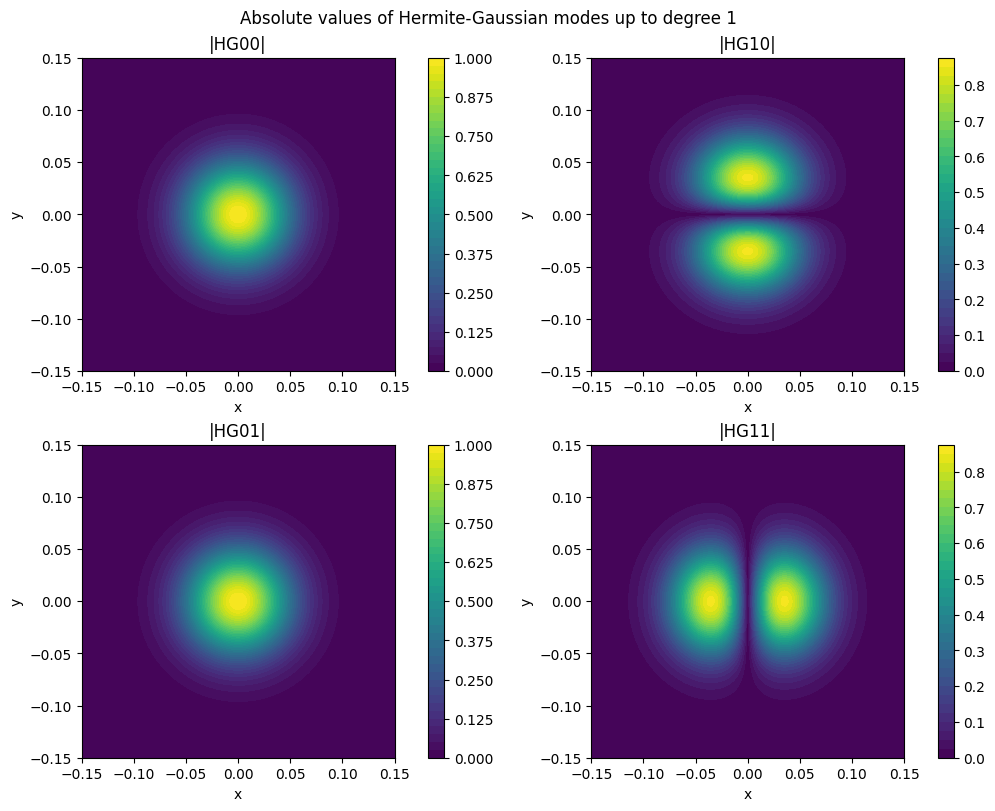

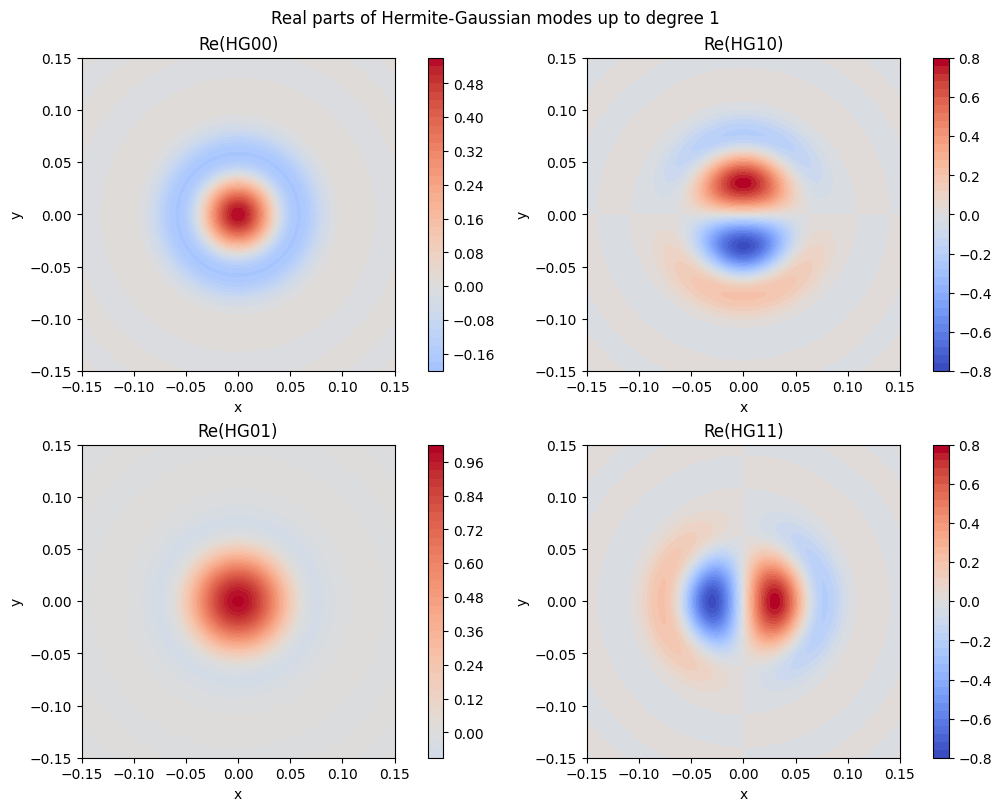

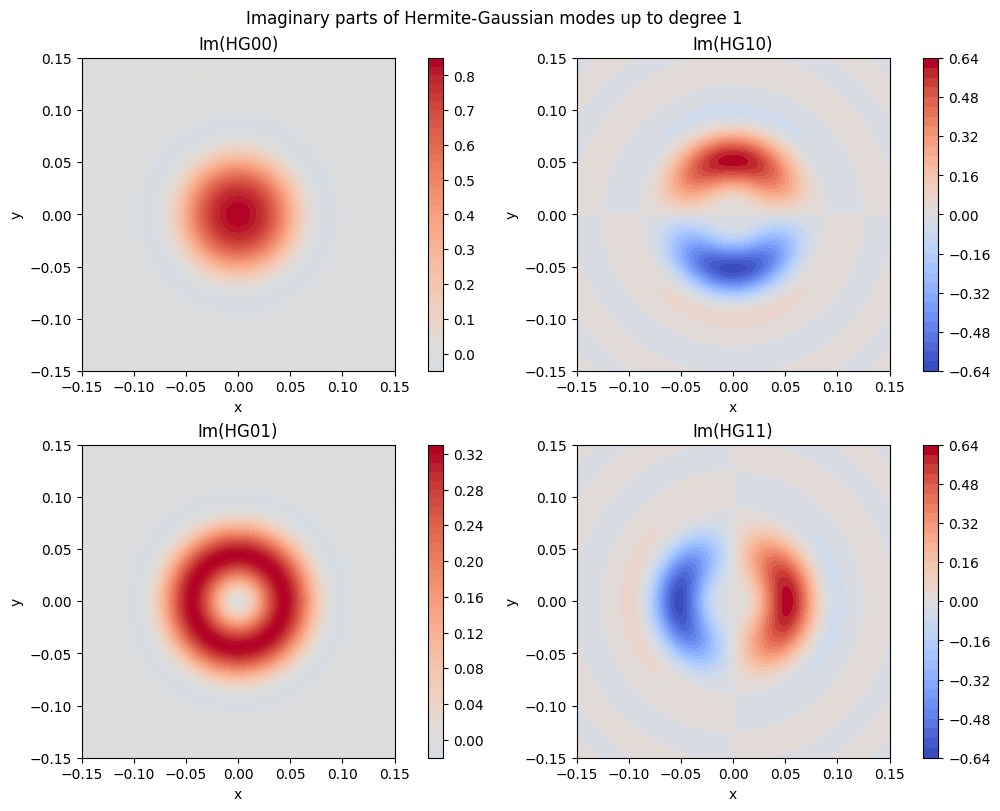

In [18]:
# Plausibility check: HG_00, HG_10, HG_01, HG_11 for the complex beam_model
x_lin = np.linspace(-0.15, 0.15, 200)
y_lin = np.linspace(-0.15, 0.15, 200)

X, Y = np.meshgrid(x_lin, y_lin, indexing='ij')

x0, y0 = 0.0, 0.0
A = 1.0
s = 0.05
kappa = 400.0

modes = [
    ('HG00', (1.0, 0.0, 0.0, 0.0)),
    ('HG10', (0.0, 0.0, 1.0, 0.0)),
    ('HG01', (0.0, 1.0, 0.0, 0.0)),
    ('HG11', (0.0, 0.0, 0.0, 1.0)),
]

fields = [(name, beam_model(X, Y, x0, y0, A, s, kappa, *w)) for name, w in modes]

# 1) Absolute values
fig_abs, axes_abs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, (name, field) in zip(axes_abs.ravel(), fields):
    amp = np.abs(field)
    im = ax.contourf(X, Y, amp, levels=40, cmap='viridis')
    ax.set_title(f'|{name}|')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    fig_abs.colorbar(im, ax=ax)
fig_abs.suptitle('Absolute values of Hermite-Gaussian modes up to degree 1')

# 2) Real parts
fig_re, axes_re = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, (name, field) in zip(axes_re.ravel(), fields):
    re_field = np.real(field)
    vmax = np.nanmax(np.abs(re_field))
    vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1.0
    im = ax.contourf(X, Y, re_field, levels=40, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Re({name})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    fig_re.colorbar(im, ax=ax)
fig_re.suptitle('Real parts of Hermite-Gaussian modes up to degree 1')

# 3) Imaginary parts
fig_im, axes_im = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, (name, field) in zip(axes_im.ravel(), fields):
    im_field = np.imag(field)
    vmax = np.nanmax(np.abs(im_field))
    vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1.0
    im = ax.contourf(X, Y, im_field, levels=40, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Im({name})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    fig_im.colorbar(im, ax=ax)
fig_im.suptitle('Imaginary parts of Hermite-Gaussian modes up to degree 1')

plt.show()

In [19]:
class BeamFit(object):
    def __init__(
        self,
        sqrt_Dgamma_reduced,
        frequencies,
        x_reduced,
        y_reduced,
        kappa_max=800.0,
        kappa_reg=1e-4,
        center_reg=1e-3,
        s_bounds=None,
    ):
        self.sqrt_Dgamma_reduced = sqrt_Dgamma_reduced
        self.frequencies = frequencies
        self.x_reduced = np.asarray(x_reduced, dtype=float).ravel()
        self.y_reduced = np.asarray(y_reduced, dtype=float).ravel()
        self.kappa_max = float(kappa_max)
        self.kappa_reg = float(kappa_reg)
        self.center_reg = float(center_reg)

        self.x_min = float(np.nanmin(self.x_reduced))
        self.x_max = float(np.nanmax(self.x_reduced))
        self.y_min = float(np.nanmin(self.y_reduced))
        self.y_max = float(np.nanmax(self.y_reduced))

        self.x_center = 0.5 * (self.x_min + self.x_max)
        self.y_center = 0.5 * (self.y_min + self.y_max)
        self.x_scale = max(0.5 * (self.x_max - self.x_min), 1e-12)
        self.y_scale = max(0.5 * (self.y_max - self.y_min), 1e-12)

        if s_bounds is None:
            dx = np.diff(np.unique(np.sort(self.x_reduced)))
            dy = np.diff(np.unique(np.sort(self.y_reduced)))
            dx_min = float(np.nanmin(dx)) if dx.size else (self.x_max - self.x_min) / 20.0
            dy_min = float(np.nanmin(dy)) if dy.size else (self.y_max - self.y_min) / 20.0
            s_min = max(0.5 * min(abs(dx_min), abs(dy_min)), 1e-6)
            s_max = max(0.75 * np.hypot(self.x_max - self.x_min, self.y_max - self.y_min), s_min * 1.1)
        else:
            s_min, s_max = map(float, s_bounds)
            if not np.isfinite(s_min) or not np.isfinite(s_max) or s_min <= 0 or s_max <= s_min:
                raise ValueError("Invalid s_bounds. Expected (s_min, s_max) with 0 < s_min < s_max.")
        self.s_min = float(s_min)
        self.s_max = float(s_max)

    def _build_bounds(self, n_params):
        bounds = [
            (self.x_min, self.x_max),
            (self.y_min, self.y_max),
            (0.0, np.inf),
            (self.s_min, self.s_max),
        ]
        if n_params >= 5:
            bounds.append((-self.kappa_max, self.kappa_max))
        if n_params >= 6:
            bounds.append((-np.pi, np.pi))
        if n_params > 6:
            bounds.extend([(-np.inf, np.inf)] * (n_params - 6))
        return bounds

    @staticmethod
    def _best_complex_scale(model, data):
        den = np.vdot(model, model).real
        if not np.isfinite(den) or den <= np.finfo(float).eps:
            return 1.0 + 0.0j
        return np.vdot(model, data) / den

    @staticmethod
    def _wrap_phase_pi(phi):
        return (phi + np.pi) % (2.0 * np.pi) - np.pi

    def _absorb_alpha_into_params(self, fit_param, z_ix, f_ix):
        p = np.asarray(fit_param, dtype=float).copy()

        x0, y0, A, s = p[:4]
        kappa = float(p[4]) if p.size >= 5 else 0.0
        phi0 = float(p[5]) if p.size >= 6 else 0.0
        w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0

        model_base = beam_model(self.x_reduced, self.y_reduced, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)
        data = self.sqrt_Dgamma_reduced[:, z_ix, f_ix]

        mask = np.isfinite(data) & np.isfinite(model_base)
        if np.any(mask):
            alpha = self._best_complex_scale(model_base[mask], data[mask])
        else:
            alpha = 1.0 + 0.0j

        p[2] = p[2] * np.abs(alpha)
        if p.size >= 6:
            p[5] = self._wrap_phase_pi(p[5] + float(np.angle(alpha)))

        return p, alpha

    def cost(self, fit_param, z_ix, f_ix):
        x0, y0, A, s = fit_param[:4]
        kappa = float(fit_param[4]) if len(fit_param) >= 5 else 0.0
        phi0 = float(fit_param[5]) if len(fit_param) >= 6 else 0.0
        w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0

        model_base = beam_model(self.x_reduced, self.y_reduced, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)
        data = self.sqrt_Dgamma_reduced[:, z_ix, f_ix]

        mask = np.isfinite(data) & np.isfinite(model_base)
        if not np.any(mask):
            return np.inf

        alpha = self._best_complex_scale(model_base[mask], data[mask])
        model_output = alpha * model_base

        mse = np.nanmean(np.abs(data - model_output) ** 2)
        reg_kappa = self.kappa_reg * (kappa / max(self.kappa_max, 1e-12)) ** 2
        reg_center = self.center_reg * (
            ((x0 - self.x_center) / self.x_scale) ** 2
            + ((y0 - self.y_center) / self.y_scale) ** 2
        )
        return float(mse + reg_kappa + reg_center)

    def fit_slice(self, start, z_ix, f_ix, disp=False):
        bounds = self._build_bounds(len(start))
        start = np.asarray(start, dtype=float).copy()
        start[0] = np.clip(start[0], self.x_min, self.x_max)
        start[1] = np.clip(start[1], self.y_min, self.y_max)
        start[3] = np.clip(start[3], self.s_min, self.s_max)
        if start.size >= 5:
            start[4] = np.clip(start[4], -self.kappa_max, self.kappa_max)
        if start.size >= 6:
            start[5] = np.clip(start[5], -np.pi, np.pi)
        res = minimize(
            self.cost, start, method='L-BFGS-B', args=(z_ix, f_ix), bounds=bounds,
            options={'maxiter': 500}
        )

        res.x_raw = np.asarray(res.x, dtype=float).copy()
        p_absorbed, alpha = self._absorb_alpha_into_params(res.x, z_ix, f_ix)
        res.alpha = alpha
        res.x = p_absorbed

        if disp:
            print(f'z={z_ix}, f={f_ix}, fit={res.x}, cost={res.fun}, success={res.success}, alpha={res.alpha}')
        return res

    def fit_all(self, start=None, disp=False):
        if start is None:
            s0 = float(np.clip(0.05, self.s_min, self.s_max))
            start = np.array([self.x_center, self.y_center, 4e3, s0, 0.0, -np.pi / 2.0], dtype=float)
        Z = self.sqrt_Dgamma_reduced.shape[1]
        F = self.sqrt_Dgamma_reduced.shape[2]
        self.params = np.full((Z, F, start.size), np.nan)
        self.costs = np.full((Z, F), np.nan)
        self.success = np.zeros((Z, F), dtype=bool)
        progress_bar = tqdm(total=Z*F, desc='E-field fit', unit='fit')
        for z in range(Z):
            for f in range(F):
                res = self.fit_slice(start, z, f, False)
                self.params[z, f, :] = res.x
                self.costs[z, f] = res.fun
                self.success[z, f] = res.success
                progress_bar.set_postfix(z=z, f=f, cost=float(res.fun))
                progress_bar.update(1)
            if disp:
                tqdm.write(f'z={z}, f={self.frequencies[250]*1e-9:.2f} GHz, fit={self.params[z, 250, :]}, cost={res.fun}, success={res.success}')
        progress_bar.close()
        return self.params, self.costs, self.success

In [20]:
import multiprocessing as mp
import os
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed

_beamfit_worker_state = {}

def _beamfit_worker_init(
    sqrt_dgamma_reduced,
    x_reduced,
    y_reduced,
    kappa_max,
    kappa_reg,
    center_reg,
    x_min,
    x_max,
    y_min,
    y_max,
    x_center,
    y_center,
    x_scale,
    y_scale,
    s_min,
    s_max,
):
    global _beamfit_worker_state
    _beamfit_worker_state = {
        'sqrt_dgamma_reduced': sqrt_dgamma_reduced,
        'x_reduced': x_reduced,
        'y_reduced': y_reduced,
        'kappa_max': float(kappa_max),
        'kappa_reg': float(kappa_reg),
        'center_reg': float(center_reg),
        'x_min': float(x_min),
        'x_max': float(x_max),
        'y_min': float(y_min),
        'y_max': float(y_max),
        'x_center': float(x_center),
        'y_center': float(y_center),
        'x_scale': float(x_scale),
        'y_scale': float(y_scale),
        's_min': float(s_min),
        's_max': float(s_max),
    }

def _beamfit_worker_best_complex_scale(model, data):
    den = np.vdot(model, model).real
    if not np.isfinite(den) or den <= np.finfo(float).eps:
        return 1.0 + 0.0j
    return np.vdot(model, data) / den

def _wrap_phase_pi(phi):
    return (phi + np.pi) % (2.0 * np.pi) - np.pi

def _beamfit_worker_task(task):
    z_ix, f_ix, start = task
    sqrt_dgamma_reduced = _beamfit_worker_state['sqrt_dgamma_reduced']
    x_reduced = _beamfit_worker_state['x_reduced']
    y_reduced = _beamfit_worker_state['y_reduced']
    kappa_max = _beamfit_worker_state['kappa_max']
    kappa_reg = _beamfit_worker_state['kappa_reg']
    center_reg = _beamfit_worker_state['center_reg']
    x_min = _beamfit_worker_state['x_min']
    x_max = _beamfit_worker_state['x_max']
    y_min = _beamfit_worker_state['y_min']
    y_max = _beamfit_worker_state['y_max']
    x_center = _beamfit_worker_state['x_center']
    y_center = _beamfit_worker_state['y_center']
    x_scale = _beamfit_worker_state['x_scale']
    y_scale = _beamfit_worker_state['y_scale']
    s_min = _beamfit_worker_state['s_min']
    s_max = _beamfit_worker_state['s_max']

    def _cost(fit_param):
        x0, y0, A, s = fit_param[:4]
        kappa = float(fit_param[4]) if len(fit_param) >= 5 else 0.0
        phi0 = float(fit_param[5]) if len(fit_param) >= 6 else 0.0
        w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0
        model_base = beam_model(x_reduced, y_reduced, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)
        data = sqrt_dgamma_reduced[:, z_ix, f_ix]

        mask = np.isfinite(data) & np.isfinite(model_base)
        if not np.any(mask):
            return np.inf

        alpha = _beamfit_worker_best_complex_scale(model_base[mask], data[mask])
        model_output = alpha * model_base

        mse = np.nanmean(np.abs(data - model_output) ** 2)
        reg_kappa = kappa_reg * (kappa / max(kappa_max, 1e-12))**2
        reg_center = center_reg * (
            ((x0 - x_center) / x_scale) ** 2
            + ((y0 - y_center) / y_scale) ** 2
        )
        return float(mse + reg_kappa + reg_center)

    bounds = [(x_min, x_max), (y_min, y_max), (0.0, np.inf), (s_min, s_max)]
    if len(start) >= 5:
        bounds.append((-kappa_max, kappa_max))
    if len(start) >= 6:
        bounds.append((-np.pi, np.pi))
    if len(start) > 6:
        bounds.extend([(-np.inf, np.inf)] * (len(start) - 6))

    start_local = np.asarray(start, dtype=float).copy()
    start_local[0] = np.clip(start_local[0], x_min, x_max)
    start_local[1] = np.clip(start_local[1], y_min, y_max)
    start_local[3] = np.clip(start_local[3], s_min, s_max)
    if start_local.size >= 5:
        start_local[4] = np.clip(start_local[4], -kappa_max, kappa_max)
    if start_local.size >= 6:
        start_local[5] = np.clip(start_local[5], -np.pi, np.pi)

    res = minimize(_cost, start_local, method='L-BFGS-B', bounds=bounds, options={'maxiter': 500})

    p_raw = np.asarray(res.x, dtype=float).copy()
    x0, y0, A, s = p_raw[:4]
    kappa = float(p_raw[4]) if p_raw.size >= 5 else 0.0
    phi0 = float(p_raw[5]) if p_raw.size >= 6 else 0.0
    w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0

    model_base = beam_model(x_reduced, y_reduced, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)
    data = sqrt_dgamma_reduced[:, z_ix, f_ix]
    mask = np.isfinite(data) & np.isfinite(model_base)

    if np.any(mask):
        alpha = _beamfit_worker_best_complex_scale(model_base[mask], data[mask])
    else:
        alpha = 1.0 + 0.0j

    p_absorbed = p_raw.copy()
    p_absorbed[2] = p_absorbed[2] * np.abs(alpha)
    if p_absorbed.size >= 6:
        p_absorbed[5] = _wrap_phase_pi(p_absorbed[5] + float(np.angle(alpha)))

    return z_ix, f_ix, p_absorbed, float(res.fun), bool(res.success)

class BeamFit(object):
    def __init__(
        self,
        sqrt_Dgamma_reduced,
        frequencies,
        x_reduced,
        y_reduced,
        kappa_max=800.0,
        kappa_reg=1e-4,
        center_reg=1e-3,
        s_bounds=None,
    ):
        self.sqrt_Dgamma_reduced = sqrt_Dgamma_reduced
        self.frequencies = frequencies
        self.x_reduced = np.asarray(x_reduced, dtype=float).ravel()
        self.y_reduced = np.asarray(y_reduced, dtype=float).ravel()
        self.kappa_max = float(kappa_max)
        self.kappa_reg = float(kappa_reg)
        self.center_reg = float(center_reg)

        self.x_min = float(np.nanmin(self.x_reduced))
        self.x_max = float(np.nanmax(self.x_reduced))
        self.y_min = float(np.nanmin(self.y_reduced))
        self.y_max = float(np.nanmax(self.y_reduced))

        self.x_center = 0.5 * (self.x_min + self.x_max)
        self.y_center = 0.5 * (self.y_min + self.y_max)
        self.x_scale = max(0.5 * (self.x_max - self.x_min), 1e-12)
        self.y_scale = max(0.5 * (self.y_max - self.y_min), 1e-12)

        if s_bounds is None:
            dx = np.diff(np.unique(np.sort(self.x_reduced)))
            dy = np.diff(np.unique(np.sort(self.y_reduced)))
            dx_min = float(np.nanmin(dx)) if dx.size else (self.x_max - self.x_min) / 20.0
            dy_min = float(np.nanmin(dy)) if dy.size else (self.y_max - self.y_min) / 20.0
            s_min = max(0.5 * min(abs(dx_min), abs(dy_min)), 1e-6)
            s_max = max(0.75 * np.hypot(self.x_max - self.x_min, self.y_max - self.y_min), s_min * 1.1)
        else:
            s_min, s_max = map(float, s_bounds)
            if not np.isfinite(s_min) or not np.isfinite(s_max) or s_min <= 0 or s_max <= s_min:
                raise ValueError("Invalid s_bounds. Expected (s_min, s_max) with 0 < s_min < s_max.")
        self.s_min = float(s_min)
        self.s_max = float(s_max)

    def _build_bounds(self, n_params):
        bounds = [
            (self.x_min, self.x_max),
            (self.y_min, self.y_max),
            (0.0, np.inf),
            (self.s_min, self.s_max),
        ]
        if n_params >= 5:
            bounds.append((-self.kappa_max, self.kappa_max))
        if n_params >= 6:
            bounds.append((-np.pi, np.pi))
        if n_params > 6:
            bounds.extend([(-np.inf, np.inf)] * (n_params - 6))
        return bounds

    @staticmethod
    def _best_complex_scale(model, data):
        den = np.vdot(model, model).real
        if not np.isfinite(den) or den <= np.finfo(float).eps:
            return 1.0 + 0.0j
        return np.vdot(model, data) / den

    @staticmethod
    def _wrap_phase_pi(phi):
        return (phi + np.pi) % (2.0 * np.pi) - np.pi

    def _absorb_alpha_into_params(self, fit_param, z_ix, f_ix):
        p = np.asarray(fit_param, dtype=float).copy()

        x0, y0, A, s = p[:4]
        kappa = float(p[4]) if p.size >= 5 else 0.0
        phi0 = float(p[5]) if p.size >= 6 else 0.0
        w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0

        model_base = beam_model(self.x_reduced, self.y_reduced, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)
        data = self.sqrt_Dgamma_reduced[:, z_ix, f_ix]

        mask = np.isfinite(data) & np.isfinite(model_base)
        if np.any(mask):
            alpha = self._best_complex_scale(model_base[mask], data[mask])
        else:
            alpha = 1.0 + 0.0j

        p[2] = p[2] * np.abs(alpha)
        if p.size >= 6:
            p[5] = self._wrap_phase_pi(p[5] + float(np.angle(alpha)))

        return p, alpha

    def cost(self, fit_param, z_ix, f_ix):
        x0, y0, A, s = fit_param[:4]
        kappa = float(fit_param[4]) if len(fit_param) >= 5 else 0.0
        phi0 = float(fit_param[5]) if len(fit_param) >= 6 else 0.0
        w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0
        model_base = beam_model(self.x_reduced, self.y_reduced, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)
        data = self.sqrt_Dgamma_reduced[:, z_ix, f_ix]

        mask = np.isfinite(data) & np.isfinite(model_base)
        if not np.any(mask):
            return np.inf

        alpha = self._best_complex_scale(model_base[mask], data[mask])
        model_output = alpha * model_base

        mse = np.nanmean(np.abs(data - model_output) ** 2)
        reg_kappa = self.kappa_reg * (kappa / max(self.kappa_max, 1e-12))**2
        reg_center = self.center_reg * (
            ((x0 - self.x_center) / self.x_scale) ** 2
            + ((y0 - self.y_center) / self.y_scale) ** 2
        )
        return float(mse + reg_kappa + reg_center)

    def fit_slice(self, start, z_ix, f_ix, disp=False):
        bounds = self._build_bounds(len(start))
        start = np.asarray(start, dtype=float).copy()
        start[0] = np.clip(start[0], self.x_min, self.x_max)
        start[1] = np.clip(start[1], self.y_min, self.y_max)
        start[3] = np.clip(start[3], self.s_min, self.s_max)
        if start.size >= 5:
            start[4] = np.clip(start[4], -self.kappa_max, self.kappa_max)
        if start.size >= 6:
            start[5] = np.clip(start[5], -np.pi, np.pi)
        res = minimize(
            self.cost, start, method='L-BFGS-B', args=(z_ix, f_ix), bounds=bounds,
            options={'maxiter': 500}
        )

        res.x_raw = np.asarray(res.x, dtype=float).copy()
        p_absorbed, alpha = self._absorb_alpha_into_params(res.x, z_ix, f_ix)
        res.alpha = alpha
        res.x = p_absorbed

        if disp:
            print(f'z={z_ix}, f={f_ix}, fit={res.x}, cost={res.fun}, success={res.success}, alpha={res.alpha}')
        return res

    def fit_all(self, start=None, disp=False, n_workers=None, backend=None):
        if start is None:
            s0 = float(np.clip(0.05, self.s_min, self.s_max))
            start = np.array([self.x_center, self.y_center, 4e3, s0, 0.0, -np.pi / 2.0], dtype=float)
        else:
            start = np.asarray(start, dtype=float)

        Z = self.sqrt_Dgamma_reduced.shape[1]
        F = self.sqrt_Dgamma_reduced.shape[2]
        self.params = np.full((Z, F, start.size), np.nan)
        self.costs = np.full((Z, F), np.nan)
        self.success = np.zeros((Z, F), dtype=bool)

        n_tasks = Z * F
        if n_workers is None:
            n_workers = max(1, mp.cpu_count() - 1)
        n_workers = int(max(1, min(n_workers, n_tasks)))

        if backend is None:
            # In Windows notebooks, multiprocessing 'spawn' often has high startup/serialization overhead.
            backend = 'thread' if (os.name == 'nt' and 'ipykernel' in sys.modules) else 'process'
        if backend not in ('thread', 'process', 'sequential'):
            raise ValueError("backend must be one of {'thread', 'process', 'sequential'}")

        print(f"Using backend='{backend}' with n_workers={n_workers} for fitting {n_tasks} tasks.")

        progress_bar = tqdm(total=n_tasks, desc='E-field fit', unit='fit')

        try:
            if backend == 'thread':
                with ThreadPoolExecutor(max_workers=n_workers) as executor:
                    futures = {
                        executor.submit(self.fit_slice, start, z, f, False): (z, f)
                        for z in range(Z)
                        for f in range(F)
                    }
                    for future in as_completed(futures):
                        z, f = futures[future]
                        res = future.result()
                        self.params[z, f, :] = res.x
                        self.costs[z, f] = res.fun
                        self.success[z, f] = res.success
                        progress_bar.set_postfix(z=z, f=f, cost=float(res.fun))
                        progress_bar.update(1)

            elif backend == 'process':
                tasks = [(z, f, start) for z in range(Z) for f in range(F)]
                with mp.get_context('spawn').Pool(
                    processes=n_workers,
                    initializer=_beamfit_worker_init,
                    initargs=(
                        self.sqrt_Dgamma_reduced,
                        self.x_reduced,
                        self.y_reduced,
                        self.kappa_max,
                        self.kappa_reg,
                        self.center_reg,
                        self.x_min,
                        self.x_max,
                        self.y_min,
                        self.y_max,
                        self.x_center,
                        self.y_center,
                        self.x_scale,
                        self.y_scale,
                        self.s_min,
                        self.s_max,
                    ),
                ) as pool:
                    chunksize = max(1, n_tasks // (n_workers * 4))
                    for z, f, p, c, ok in pool.imap_unordered(_beamfit_worker_task, tasks, chunksize=chunksize):
                        self.params[z, f, :] = p
                        self.costs[z, f] = c
                        self.success[z, f] = ok
                        progress_bar.set_postfix(z=z, f=f, cost=float(c))
                        progress_bar.update(1)

            else:
                for z in range(Z):
                    for f in range(F):
                        res = self.fit_slice(start, z, f, False)
                        self.params[z, f, :] = res.x
                        self.costs[z, f] = res.fun
                        self.success[z, f] = res.success
                        progress_bar.set_postfix(z=z, f=f, cost=float(res.fun))
                        progress_bar.update(1)

        except Exception as exc:
            if disp:
                tqdm.write(f'Parallel backend unavailable ({exc}); falling back to sequential fitting.')
            for z in range(Z):
                for f in range(F):
                    res = self.fit_slice(start, z, f, False)
                    self.params[z, f, :] = res.x
                    self.costs[z, f] = res.fun
                    self.success[z, f] = res.success
                    progress_bar.set_postfix(z=z, f=f, cost=float(res.fun))
                    progress_bar.update(1)

        progress_bar.close()

        if disp and F > 250:
            for z in range(Z):
                tqdm.write(
                    f"z={z}, f={self.frequencies[250]*1e-9:.2f} GHz, "
                    f"fit={self.params[z, 250, :]}, cost={self.costs[z, 250]}, success={self.success[z, 250]}"
                )

        return self.params, self.costs, self.success

In [21]:
# Robustness patch for BeamFit to suppress pathological alpha/amplitude blow-ups
# (applies to subsequent BeamFit instances)
_BEAMFIT_ORIG_INIT = BeamFit.__init__

def _beamfit_init_robust(
    self,
    *args,
    alpha_max=1e4,
    model_norm_floor=1e-9,
    alpha_reg=1e-4,
    s_reg=1e-4,
    **kwargs,
):
    _BEAMFIT_ORIG_INIT(self, *args, **kwargs)
    self.alpha_max = float(alpha_max)
    self.model_norm_floor = float(model_norm_floor)
    self.alpha_reg = float(alpha_reg)
    self.s_reg = float(s_reg)


def _beamfit_best_complex_scale_robust(model, data, alpha_max=1e4):
    den = np.vdot(model, model).real
    if (not np.isfinite(den)) or (den <= np.finfo(float).eps):
        return 1.0 + 0.0j

    alpha = np.vdot(model, data) / den
    if not np.isfinite(alpha.real) or not np.isfinite(alpha.imag):
        return 1.0 + 0.0j

    aabs = np.abs(alpha)
    amax = float(max(alpha_max, 1.0))
    if aabs > amax:
        alpha = alpha * (amax / aabs)
    return alpha


def _beamfit_cost_robust(self, fit_param, z_ix, f_ix):
    x0, y0, A, s = fit_param[:4]
    kappa = float(fit_param[4]) if len(fit_param) >= 5 else 0.0
    phi0 = float(fit_param[5]) if len(fit_param) >= 6 else 0.0
    w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0

    model_base = beam_model(self.x_reduced, self.y_reduced, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)
    data = self.sqrt_Dgamma_reduced[:, z_ix, f_ix]

    mask = np.isfinite(data) & np.isfinite(model_base)
    if not np.any(mask):
        return np.inf

    model_rms = np.sqrt(np.nanmean(np.abs(model_base[mask]) ** 2))
    if (not np.isfinite(model_rms)) or (model_rms < self.model_norm_floor):
        return np.inf

    alpha = BeamFit._best_complex_scale(model_base[mask], data[mask], alpha_max=self.alpha_max)
    model_output = alpha * model_base

    mse = np.nanmean(np.abs(data - model_output) ** 2)
    reg_kappa = self.kappa_reg * (kappa / max(self.kappa_max, 1e-12)) ** 2
    reg_center = self.center_reg * (
        ((x0 - self.x_center) / self.x_scale) ** 2
        + ((y0 - self.y_center) / self.y_scale) ** 2
    )

    s_mid = 0.5 * (self.s_min + self.s_max)
    s_span = max(0.5 * (self.s_max - self.s_min), 1e-12)
    reg_s = self.s_reg * ((s - s_mid) / s_span) ** 2

    reg_alpha = self.alpha_reg * (np.abs(alpha) / max(self.alpha_max, 1.0)) ** 2

    return float(mse + reg_kappa + reg_center + reg_s + reg_alpha)


def _beamfit_absorb_alpha_robust(self, fit_param, z_ix, f_ix):
    p = np.asarray(fit_param, dtype=float).copy()

    x0, y0, A, s = p[:4]
    kappa = float(p[4]) if p.size >= 5 else 0.0
    phi0 = float(p[5]) if p.size >= 6 else 0.0
    w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0

    model_base = beam_model(self.x_reduced, self.y_reduced, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)
    data = self.sqrt_Dgamma_reduced[:, z_ix, f_ix]

    mask = np.isfinite(data) & np.isfinite(model_base)
    if np.any(mask):
        alpha = BeamFit._best_complex_scale(model_base[mask], data[mask], alpha_max=self.alpha_max)
    else:
        alpha = 1.0 + 0.0j

    p[2] = p[2] * np.abs(alpha)
    if p.size >= 6:
        p[5] = BeamFit._wrap_phase_pi(p[5] + float(np.angle(alpha)))

    return p, alpha


BeamFit.__init__ = _beamfit_init_robust
BeamFit._best_complex_scale = staticmethod(_beamfit_best_complex_scale_robust)
BeamFit.cost = _beamfit_cost_robust
BeamFit._absorb_alpha_into_params = _beamfit_absorb_alpha_robust

##### reduced $E_T$ calculation:

In [22]:
def compute_ET_reduced(
    params,
    x_pos,
    y_pos,
    beam_model,
    frequencies,
    fit_costs=None,
    fit_success=None,
    cost_quantile=None,
    max_abs_A=None,
    max_abs_kappa=None,
):
    """
    Compute transverse E-field ET for each z-slice and frequency using a fresh n1 x n2
    integration grid over (x,y). Unlike beta_reduced, this does NOT integrate over z.

    Notes:
      - Uses the fitted field amplitude directly (no RMS renormalization).
      - Optional guards can be enabled via fit_success / fit_costs / parameter limits.

    Returns:
        ET_reduced: array of shape (Z, Nf) with ∫∫ E(x,y; z,f) dx dy per (z,f).
    """
    n1 = 50
    n2 = 50

    x_lin = np.linspace(np.min(x_pos), np.max(x_pos), n1)
    y_lin = np.linspace(np.min(y_pos), np.max(y_pos), n2)
    X, Y = np.meshgrid(x_lin, y_lin, indexing='ij')

    Z, Nf = params.shape[0], params.shape[1]
    ET_reduced = np.full((Z, Nf), np.nan + 0j, dtype=np.complex128)

    good_mask = np.ones((Z, Nf), dtype=bool)

    if fit_success is not None:
        fit_success = np.asarray(fit_success, dtype=bool)
        if fit_success.shape == (Z, Nf):
            good_mask &= fit_success

    if (fit_costs is not None) and (cost_quantile is not None):
        fit_costs = np.asarray(fit_costs, dtype=float)
        if fit_costs.shape == (Z, Nf):
            finite_costs = fit_costs[np.isfinite(fit_costs)]
            if finite_costs.size > 0:
                cost_thr = np.nanquantile(finite_costs, float(cost_quantile))
                good_mask &= np.isfinite(fit_costs) & (fit_costs <= cost_thr)

    for f_ix in range(Nf):
        for z_ix in range(Z):
            if not good_mask[z_ix, f_ix]:
                continue

            p = params[z_ix, f_ix, :]
            if p.size < 4 or not np.all(np.isfinite(p[:4])):
                continue

            x0, y0, A, s = map(float, p[:4])
            kappa = float(p[4]) if p.size >= 5 and np.isfinite(p[4]) else 0.0
            phi0 = float(p[5]) if p.size >= 6 and np.isfinite(p[5]) else 0.0

            if (s <= 0.0) or (not np.isfinite(s)):
                continue
            if (max_abs_A is not None) and (np.abs(A) > float(max_abs_A)):
                continue
            if (max_abs_kappa is not None) and (np.abs(kappa) > float(max_abs_kappa)):
                continue

            E_field = beam_model(X, Y, x0, y0, A, s, kappa, phi0, 1.0, 0.0, 0.0, 0.0)
            if not np.all(np.isfinite(E_field)):
                continue

            ET_reduced[z_ix, f_ix] = np.trapezoid(np.trapezoid(E_field, y_lin, axis=1), x_lin, axis=0)

    return ET_reduced

##### Execution:

Using backend='thread' with n_workers=39 for fitting 1001 tasks.


E-field fit: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:52<00:00, 18.96fit/s, cost=1.57e+4, f=1000, z=0]


Using backend='thread' with n_workers=39 for fitting 1001 tasks.


E-field fit: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:49<00:00, 20.28fit/s, cost=7.91e+3, f=1000, z=0]


Using backend='thread' with n_workers=39 for fitting 1001 tasks.


E-field fit:   3%|███                                                                                               | 31/1001 [00:48<13:20,  1.21fit/s, cost=1.75e+4, f=40, z=0]/data/dust/user/salamana/spider-bead-pull/.venv/lib64/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
E-field fit: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:57<00:00, 17.44fit/s, cost=1.57e+4, f=1000, z=0]


Using backend='thread' with n_workers=39 for fitting 1001 tasks.


E-field fit: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:59<00:00, 16.96fit/s, cost=2.36e+4, f=955, z=0]


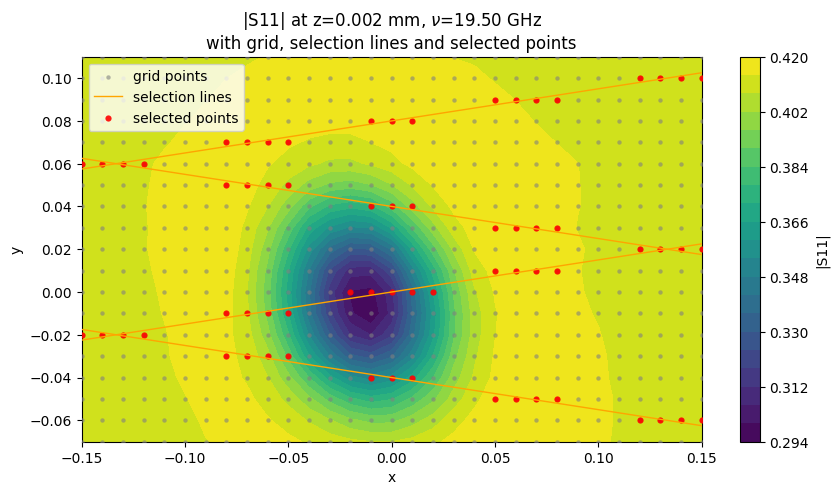

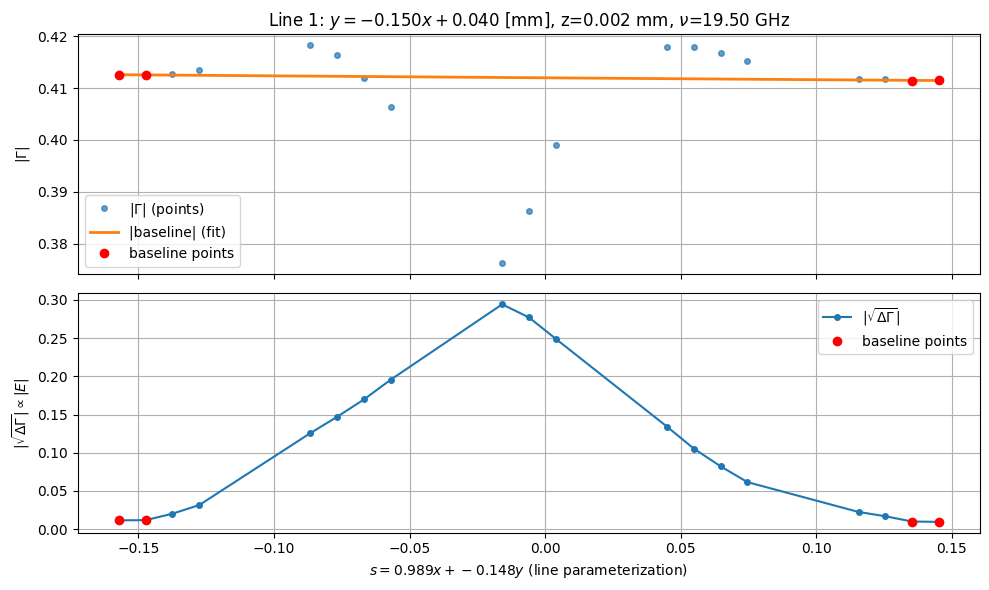

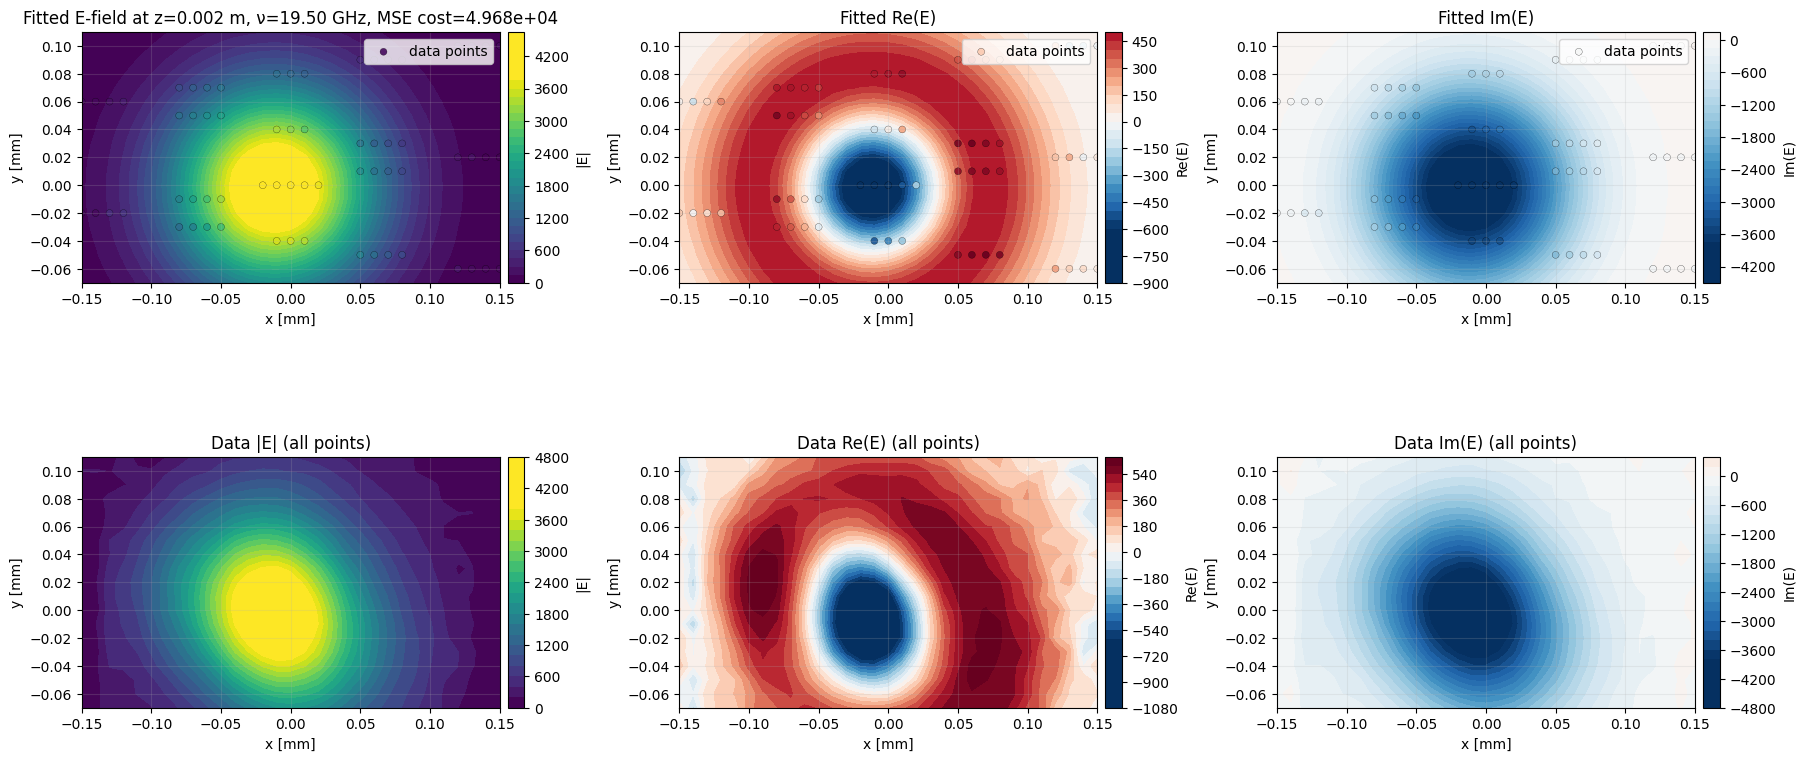

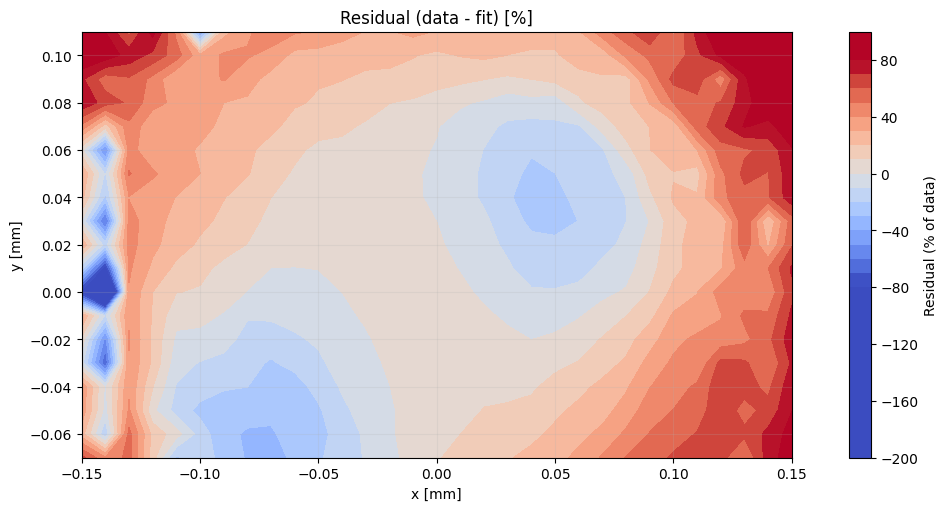

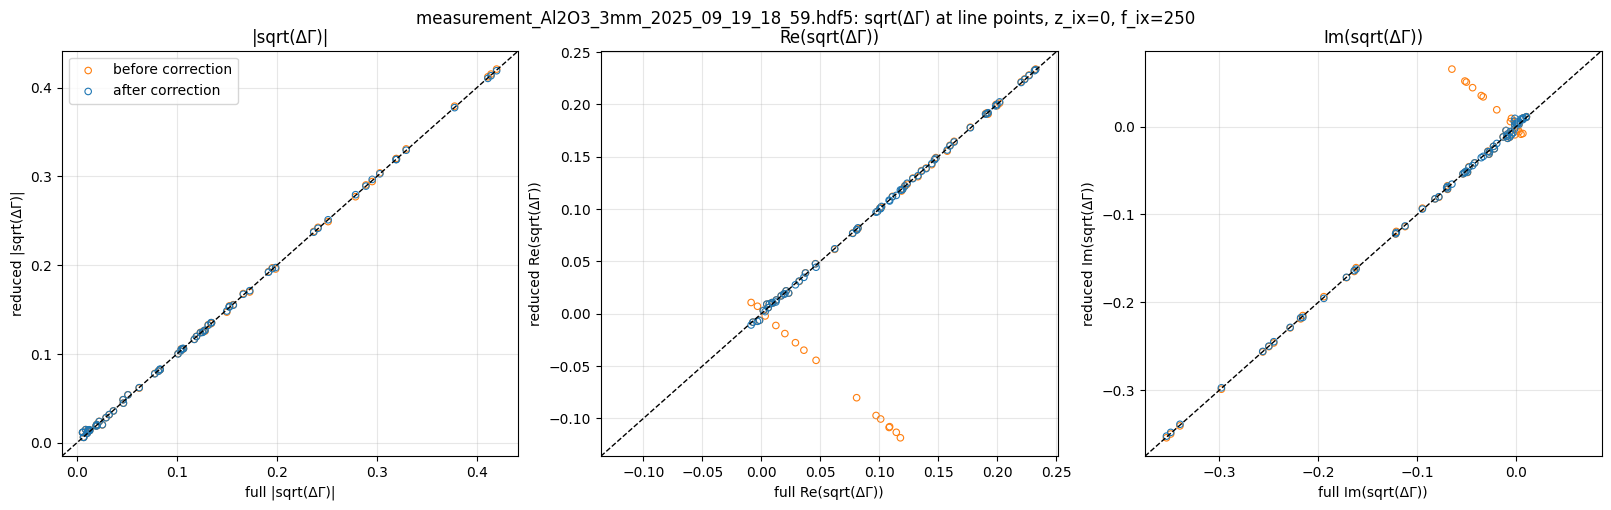

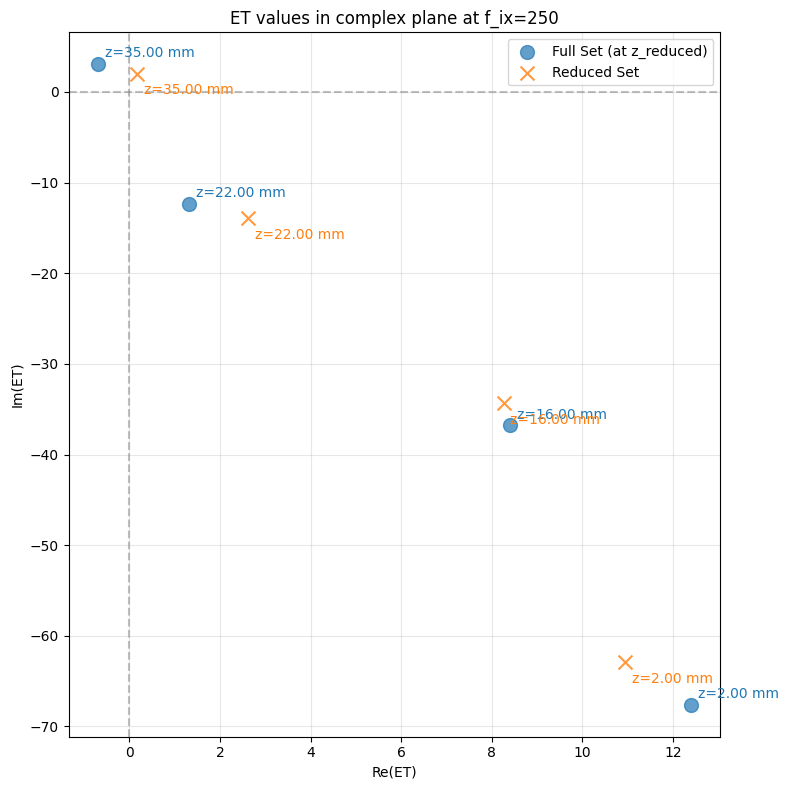

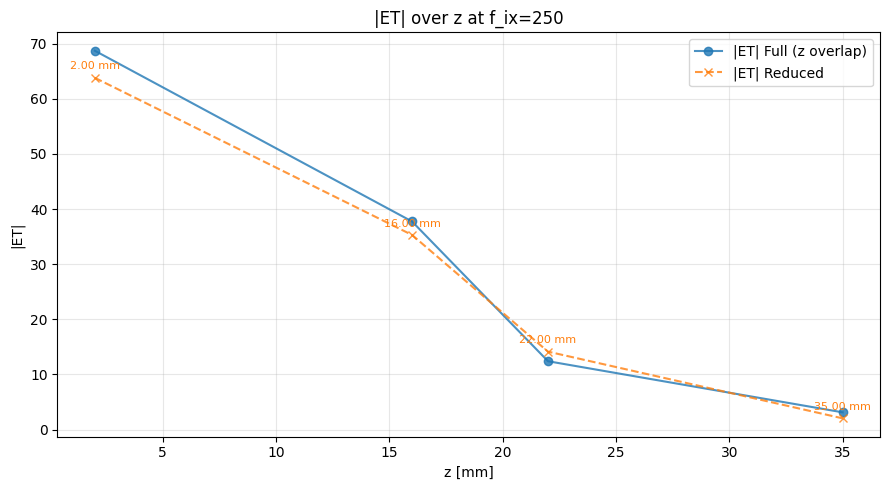

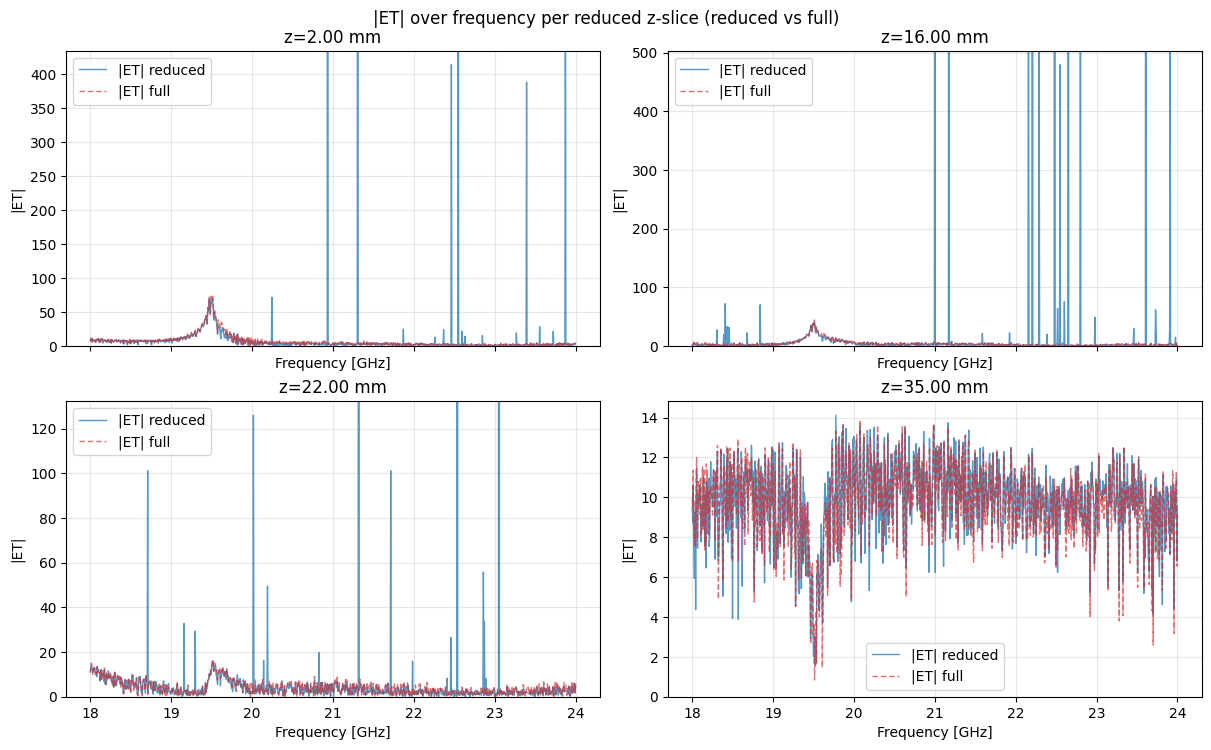

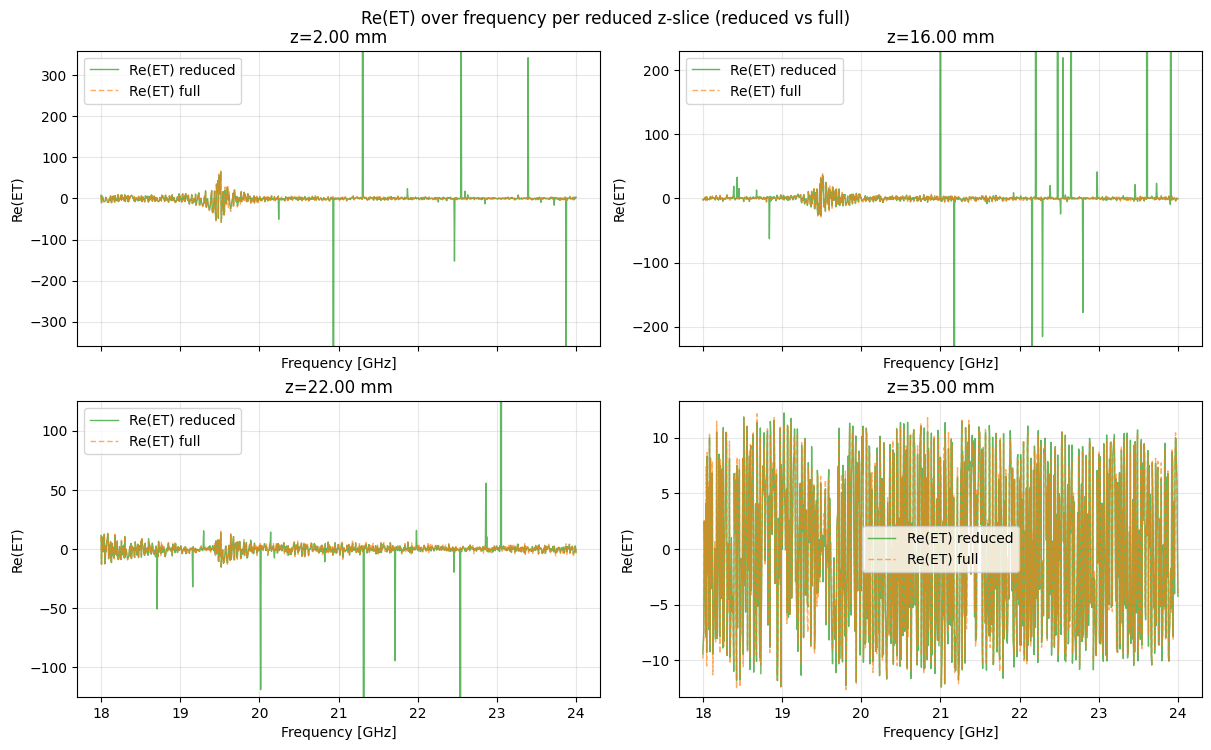

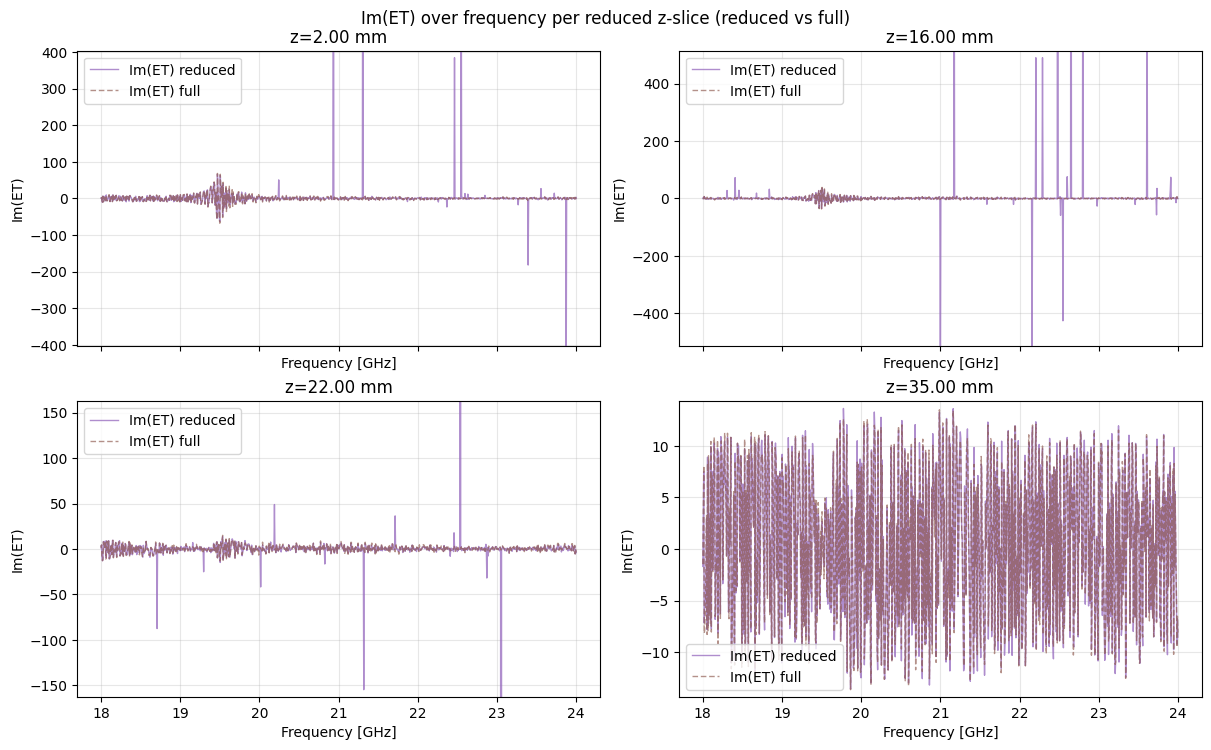

In [23]:
plot_ix = 0
data_folder = "./data/"
existing_fit_file = data_folder + 'beam_fit_results_complex.pkl'
existing_fit_file = None

if existing_fit_file is None:
    fit_results_per_file = []
else:
    with open(existing_fit_file, 'rb') as file:
        fit_results_per_file = pickle.load(file)['all_fits']    

ETs_reduced, ETs_full = [], []
z_reduced, z_full = [], []

for i, file in enumerate(files):
    s11, s11_flat, s11_z, s11_z_flat, frequencies, x_pos, x_plt, x_pts, y_pos, y_plt, y_pts, z_pos = load_file(
        measurements_directory + file,
        time_gating=True,
        t_width=180e-9,
        t_offset=55e-9,
    )

    s11_reduced, x_reduced, y_reduced, lines, all_ixs, per_line_ixs = reduce_points_to_lines(s11_z_flat, x_pts, y_pts)
    sqrt_Dgamma_reduced, sqrt_Dgamma_lines, baseline_lines, s_sorted_lines, idxs_sorted_lines = compute_sqrt_Dgamma_lines(s11_z_flat, x_pts, y_pts, lines, per_line_ixs, all_ixs, n_baseline_margin)

    # compute full sqrt(ΔΓ) and then correct reduced sqrt(ΔΓ) at line points
    sqrt_dgamma_full = compute_sqrt_Dgamma_full(s11, x_pos, y_pos, z_pos, n_baseline_margin)
    sqrt_Dgamma_reduced_corr, sqrt_Dgamma_lines_corr = correct_sqrt_dgamma_reduced_with_full(
        sqrt_dgamma_full,
        sqrt_Dgamma_lines,
        idxs_sorted_lines,
        all_ixs,
        z_ixs_used,
    )

    # convert corrected reduced data to E-field BEFORE fitting
    E_reduced = sqrt_dgamma_to_E(sqrt_Dgamma_reduced_corr, frequencies)

    if existing_fit_file is None:
        beam_fit = BeamFit(
            E_reduced,
            frequencies,
            x_reduced,
            y_reduced,
            kappa_max=800.0,
            kappa_reg=5e-4,
            center_reg=3e-3,
            s_bounds=(8e-3, 0.12),
            alpha_max=1e4,
            model_norm_floor=1e-9,
            alpha_reg=1e-4,
            s_reg=1e-4,
        )
        beam_fit.fit_all(backend='thread')
        
        fit_results_per_file += [{
            'params': beam_fit.params,
            'costs': beam_fit.costs,
            'success': beam_fit.success,
        }]
        fit_params = beam_fit.params
        fit_costs = beam_fit.costs
        fit_success = beam_fit.success
    else:
        fit_params = fit_results_per_file[i]['params']
        fit_costs = fit_results_per_file[i]['costs']
        fit_success = fit_results_per_file[i].get('success', np.ones_like(fit_costs, dtype=bool))
    
    # integrate fitted E-field model with minimal guards (no forced quantile clipping)
    ETs_reduced += list(
        compute_ET_reduced(
            fit_params,
            x_pos,
            y_pos,
            beam_model,
            frequencies,
            fit_costs=fit_costs,
            fit_success=fit_success,
            cost_quantile=None,
            max_abs_A=None,
            max_abs_kappa=None,
        )
    )
    z_reduced += list(z_pos[z_ixs_used])
    
    E_full = sqrt_dgamma_to_E(sqrt_dgamma_full, frequencies)
    ETs_full += list(compute_ET_full(E_full, x_pos, y_pos, frequencies))
    z_full += list(z_pos)
    
    if i == plot_ix:
        plot_point_selection(s11, frequencies, all_ixs, lines, x_pos, x_pts, y_pos, y_pts, z_pos, z_ix=z_ixs_used[0], f_ix=250, show_point_ix=False, show_line_ix=True)
        plot_sqrt_Dgamma_line(lines, idxs_sorted_lines, s_sorted_lines, baseline_lines, sqrt_Dgamma_lines, line_index=1, n_baseline_margin=n_baseline_margin, s11_flat=s11_z_flat, z_pos=z_pos, frequencies=frequencies, z_ix=0, f_ix=250)
        plot_fitted_efield(fit_params, x_plt, y_plt, x_reduced, y_reduced, E_reduced, E_full, beam_model, z_pos, frequencies, costs=fit_costs, z_ix=0, f_ix=250, overlay_points=True)
        plot_sqrt_dgamma_before_after_correction(sqrt_dgamma_full, sqrt_Dgamma_reduced, sqrt_Dgamma_reduced_corr, all_ixs, z_ix=0, f_ix=250, title_prefix=f"{file}:")

ETs_reduced = np.asarray(ETs_reduced)
ETs_full = np.asarray(ETs_full)
z_reduced = np.asarray(z_reduced).flatten()
z_full = np.asarray(z_full).flatten()

order_reduced = np.argsort(z_reduced)
z_reduced = z_reduced[order_reduced]
ETs_reduced = ETs_reduced[order_reduced, ...]

order_full = np.argsort(z_full)
z_full = z_full[order_full]
ETs_full = ETs_full[order_full, ...]

plot_ET_complex_plane(ETs_full, ETs_reduced, z_full, z_reduced, f_ix=250)
plot_abs_ET_over_z(ETs_full, ETs_reduced, z_full, z_reduced, f_ix=250)
plot_abs_ET_grid_over_frequency(ETs_full, ETs_reduced, z_full, z_reduced, frequencies, max_et_for_scaling=500)

if existing_fit_file is None:
    outfile_all = data_folder + 'beam_fit_results_complex.pkl'
    with open(outfile_all, 'wb') as file:
        pickle.dump({
            'all_fits': fit_results_per_file,
            'frequencies': frequencies
        }, file)
        
np.savez(
    data_folder + 'ET_results.npz',
    ETs_reduced=ETs_reduced,
    ETs_full=ETs_full, z_reduced=z_reduced,
    z_full=z_full,
    frequencies=frequencies
)

#beta_full = np.square(np.nansum(sqrt_dgamma_full, axis=(0, 1, 2)) * np.mean(np.diff(x_pos)) * np.mean(np.diff(y_pos)) * np.mean(np.diff(z_pos)))   
#beta_full, sqrt_dgamma_full = compute_beta_full(s11, x_pos, y_pos, z_pos, n_baseline_margin)
#beta_reduced = compute_beta_reduced(params, x_pos, y_pos, z_pos, beam_model)
#plot_beta_overlay(beta_reduced, beta_full)

In [33]:
z_full

array([0.002, 0.003, 0.004, 0.016, 0.017, 0.018, 0.022, 0.023, 0.024,
       0.035, 0.036, 0.037, 0.038, 0.039, 0.04 , 0.041, 0.042])

In [25]:
f_ix = 250
#ETs_reduced.shape, ETs_full.shape, z_reduced.shape, z_full.shape
ETs_reduced[:, f_ix], ETs_full[:, f_ix], z_reduced, z_full

(array([10.94236571-62.86959572j,  8.25860982-34.32470389j,
         2.61397873-13.88815729j,  0.16456898 +2.02586346j]),
 array([12.38723567-67.60067077j, 11.69627983-75.77774779j,
        12.2780612 -71.43582007j,  8.40958607-36.79551787j,
         9.11378165-42.56712116j, -9.38167845+42.63613618j,
         1.31111979-12.32405009j, -2.204016  +17.82417115j,
        -2.94363617+14.60730575j, -0.68622264 +3.04741459j,
         0.43378121 -3.45900176j,  0.52760708 -6.11004457j,
         1.17622179 -6.23565343j, -2.38286888 +4.11664709j,
         3.83879589 +5.64720859j,  1.67799854 +7.14141807j,
        -1.35402168 -0.93203915j]),
 array([0.002, 0.016, 0.022, 0.035]),
 array([0.002, 0.003, 0.004, 0.016, 0.017, 0.018, 0.022, 0.023, 0.024,
        0.035, 0.036, 0.037, 0.038, 0.039, 0.04 , 0.041, 0.042]))

In [26]:
z_reduced

array([0.002, 0.016, 0.022, 0.035])

In [27]:
t_ix = np.argmax(np.abs(ETs_reduced[3,:]))
t_ix = 899
np.abs(ETs_reduced)[:, t_ix], t_ix

(array([387.73676592,   1.07438381,   2.06065846,  10.38179088]), 899)

In [28]:
np.abs(ETs_reduced[1, 899])

np.float64(1.074383807536442)

In [29]:
ETs_reduced.shape

(4, 1001)

In [30]:
fit_params[0, 747, :]

array([-7.72472550e-02,  1.94901750e-02,  3.99999860e+07,  8.53903714e-03,
       -4.18631196e-01,  5.65845346e-01])

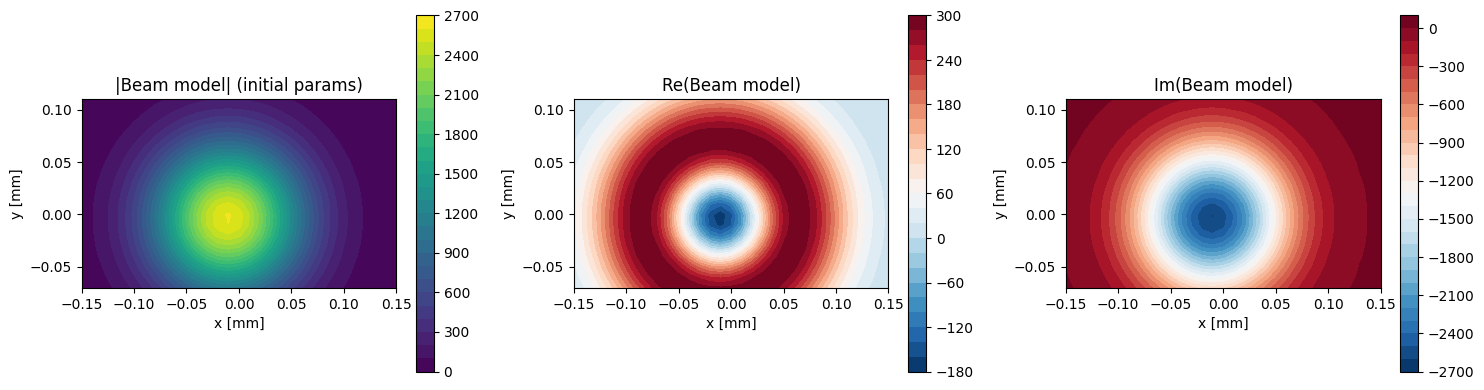

array([-1.06632478e-02, -3.65284265e-03,  2.61943741e+03,  7.08234933e-02,
        7.53132400e+01, -1.63849727e+00])

In [31]:
# Plot beam model with the initial fit parameters used by BeamFit.fit_all()
init_params = np.array([0.0, 0.0, 4e3, 0.05, 400.0, -np.pi / 2.0+.1], dtype=float)
init_params = fit_params[0, 250, :]

x0, y0, A, s, kappa, phi0 = init_params
w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0

Zm_init = beam_model(x_plt, y_plt, x0, y0, A, s, kappa, phi0, w0, w1, w2, w3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].contourf(x_plt, y_plt, np.abs(Zm_init), levels=30, cmap='viridis')
axes[0].set_title('|Beam model| (initial params)')
axes[0].set_xlabel('x [mm]')
axes[0].set_ylabel('y [mm]')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(x_plt, y_plt, np.real(Zm_init), levels=30, cmap='RdBu_r')
axes[1].set_title('Re(Beam model)')
axes[1].set_xlabel('x [mm]')
axes[1].set_ylabel('y [mm]')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(x_plt, y_plt, np.imag(Zm_init), levels=30, cmap='RdBu_r')
axes[2].set_title('Im(Beam model)')
axes[2].set_xlabel('x [mm]')
axes[2].set_ylabel('y [mm]')
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

init_params

In [32]:
# Quick check with current fit_params: reduced ET with minimal filtering
ET_test = compute_ET_reduced(
    fit_params,
    x_pos,
    y_pos,
    beam_model,
    frequencies,
    fit_costs=fit_costs,
    fit_success=fit_success if 'fit_success' in globals() else None,
    cost_quantile=None,
    max_abs_A=None,
    max_abs_kappa=None,
)

np.nanmax(np.abs(ET_test)), np.abs(ET_test[:, 250])

(np.float64(9162.785513296389), array([35.30424809]))